# **A Data‑Driven Study of the Alone TV Series**
#### **Team - 05**
### **Why we chose this project?**
Alone is s survival TV series where 10 survivalists are dropped in an extremely remote area (Arctic winter) and must fend for themselves. Its impressive to see how the winning contestants use their skills, endurance, and mental fortitude to last 100 days in such a harsh living condition.



## **Data Dictionary**
It uses a collection of datasets about the TV series:

1. `survivalists.csv`
A data frame of survivalists across all 9 seasons detailing name and demographics, location and profession, result, days lasted, reasons for tapping out (detailed and categorised), page URL.

| Feature Name   | Description |
| -------- | ------- |
| `season`  | The season number   |
| `name` | Name of the survivalist     |
| `version` | The version country code (currently only US but being preppred or other versions)|
| `id` | Survivalist unique ID |
| `age` | Age of survivalist |
| `gender` | Gender |
| `city` |  City |
| `state` | State |
| `country` | Country |
|`result`| Place the survivalist finished in the season|
| `days_lasted` | The number of days lasted in the game before tapping out or winning|
| `medically_evacuated` | Logical. If the survivalist was medically evacuated from the game |
| `reason_tapped_out` | The reason the survivalist tapped out of the game. NA means they were the winner |
| `reason_category` | A simplified category of the reason for tapping out |
| `team` | The team they were associated with (only for season 4)|
| `day_linked_up` | Day the team members linked up |
| `profession` | Profession of the survivalist |
---

2. `episodes.csv`
This dataset contains details of each episode including the title, number of viewers, beginning quote and IMDb rating.

| Feature Name   | Description |
| -------- | ------- |
| `version` | Country code for the version of the show |
| `season` | The season number |
| `episode_number_overall` | Episode number across seasons |
| `episode` | Episode number |
| `title` | Episode title |
| `air_date` | Date the episode originally aired |
| `viewers` | Number of viewers in the US (millions) |
| `quote` | The beginning quote |
| `author` | Author of the beginning quote |
|`imdb_rating` | IMDb rating of the episode |
| `n_ratings` | Number of ratings given for the episode |
----

3. `seasons.csv`
The season summary dataset includes location, latitude and longitude, and other season level information. It includes the date of drop off where the information exists.

| Feature Name   | Description |
| -------- | ------- |
| `version` | Country code for the version of the show |
| `season` | The season number |
| `location` | Location |
| `country` | Country |
| `n_survivors` | Number of survivalists in the season. In season 4 there were 7 teams of 2 |
| `lat` | Latitude |
| `lon` | Longitude |
| `date_drop_off` | The date the survivalists were dropped off |
---

4. `loadouts.csv`
Each survivalist is allowed to take with them 10 items. This dataset includes information on each survivalist’s loadout.

| Feature Name   | Description |
| -------- | ------- |
| `version` | Country code for the version of the show |
| `season` | The season number |
| `id` | Survivalist unique ID |
| `name` | Name of the survivalist |
| `item_number` | Item number |
| `item_detailed` | Detailed loadout item description |
| `item` | Loadout item. Simplified for aggregation |

## **Installing Neccessary Libraries**

In [ ]:
!pip install psynlig -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.7/458.7 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.3 MB/s eta 0:00:00


In [ ]:
!pip install umap-learn -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **Merging Datasets**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# epi = pd.read_csv('/content/drive/MyDrive/Spring2026/UnsupervisedML/BA820TeamProject/episodes.csv')
# ses = pd.read_csv('/content/drive/MyDrive/Spring2026/UnsupervisedML/BA820TeamProject/seasons.csv')
# sur = pd.read_csv('/content/drive/MyDrive/Spring2026/UnsupervisedML/BA820TeamProject/survivalists.csv')
# load = pd.read_csv('/content/drive/MyDrive/Spring2026/UnsupervisedML/BA820TeamProject/loadouts.csv')
epi = pd.read_csv('/content/drive/MyDrive/Spring2026/UnsupervisedML/Assignment/episodes.csv')
ses = pd.read_csv('/content/drive/MyDrive/Spring2026/UnsupervisedML/Assignment/seasons.csv')
sur = pd.read_csv('/content/drive/MyDrive/Spring2026/UnsupervisedML/Assignment/survivalists.csv')
load = pd.read_csv('/content/drive/MyDrive/Spring2026/UnsupervisedML/Assignment/loadouts.csv')
# epi = pd.read_csv('/content/drive/MyDrive/AloneTVshow/episodes.csv')
# ses = pd.read_csv('/content/drive/MyDrive/AloneTVshow/seasons.csv')
# sur = pd.read_csv('/content/drive/MyDrive/AloneTVshow/survivalists.csv')
# load = pd.read_csv('/content/drive/MyDrive/AloneTVshow/loadouts.csv')

In [ ]:
# -----------------------------
# 1. Normalize version column
# -----------------------------

for _df in [epi, ses, sur, load]:
    if 'version' not in _df.columns:
        _df['version'] = 'US'

if 'id' not in sur.columns:
    sur = sur.copy()
    sur['id'] = sur['name']  # fallback to name as unique identifier

if 'id' not in load.columns:
    load = load.copy()
    load['id'] = load['name']  # fallback for loadouts


# -------------------------------------------------
# 2. CONTESTANT DATA
# -------------------------------------------------

df = (
    sur.merge(
        ses[['version','season','location','lat','lon','date_drop_off']],
        on=['version','season'],
        how='left'
    )
    .groupby(['version','season','id','name'], as_index=False)
    .agg({
        'age': 'first',
        'gender': 'first',
        'profession': 'first',
        'city': 'first',
        'state': 'first',
        'country': 'first',
        'days_lasted': 'max',
        'result': 'first',
        'medically_evacuated': 'first',
        'reason_category': 'first',
        'location': 'first',
        'lat': 'first',
        'lon': 'first',
        'date_drop_off': 'first',
        'team':'first'
    })
)

# Hard guarantee: no duplicate people
assert df[['version','season','id']].duplicated().sum() == 0


# -------------------------------------------------
# 3. EPISODE DATA
# -------------------------------------------------

epi_season = (
    epi.groupby(['version','season'], as_index=False)
       .agg({
           'viewers': 'mean',
           'imdb_rating': 'mean',
           'n_ratings': 'mean'
       })
)

df = df.merge(
    epi_season,
    on=['version','season'],
    how='left'
)


# -------------------------------------------------
# 4. LOADOUT DATA
# -------------------------------------------------

load_person = (
    load[['version','season','id','item','item_detailed']]
    .drop_duplicates()
    .groupby(['version','season','id'], as_index=False)
    .agg({'item': list, 'item_detailed' : list})
)


df = df.merge(
    load_person,
    on=['version','season','id'],
    how='left'
)

df.head()

,version,season,id,name,age,gender,profession,city,state,country,...,location,lat,lon,date_drop_off,team,viewers,imdb_rating,n_ratings,item,item_detailed
0,US,1,Alan Kay,Alan Kay,40,Male,Corrections Officer,Blairsville,Georgia,United States,...,Quatsino,50.72444,-127.498056,None,None,1.9697,7.672727,101.545455,"[Saw, Axe, Sleeping bag, Pot, Ferro rod, Cante...","[Saw, Axe, Sleeping bag, Large 2-quart pot, Fe..."
1,US,1,Brant McGee,Brant McGee,44,Male,US Army Guard and Former US Coast Guard,Albemarle,North Carolina,United States,...,Quatsino,50.72444,-127.498056,None,None,1.9697,7.672727,101.545455,"[Tarp, Paracord, Axe, Sleeping bag, Pot, Ferro...","[12×12 ground sheet tarp, 550 paracord – 20m, ..."
2,US,1,Chris Weatherman,Chris Weatherman,41,Male,Author,Umatilla,Florida,United States,...,Quatsino,50.72444,-127.498056,None,None,1.9697,7.672727,101.545455,"[Saw, Axe, Sleeping bag, Ferro rod, Pot, Cante...","[Saw, Axe, Sleeping bag, Ferro rod, Large 2 qu..."
3,US,1,Dustin Feher,Dustin Feher,37,Male,Carpenter,Pittsburgh,Pennsylvania,United States,...,Quatsino,50.72444,-127.498056,None,None,1.9697,7.672727,101.545455,"[Paracord, Axe, Sleeping bag, Pot, Ferro rod, ...","[550 paracord – 20m, Axe, Sleeping bag, Large ..."
4,US,1,Joe Robinet,Joe Robinet,24,Male,Carpenter,Windsor,Ontario,Canada,...,Quatsino,50.72444,-127.498056,None,None,1.9697,7.672727,101.545455,"[Tarp, Paracord, Axe, Sleeping bag, Pot, Ferro...","[12x 12 tarp, 550 paracord – 20m, Axe, Sleepin..."


# **1. Data Preprocessing**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   version              94 non-null     object 
 1   season               94 non-null     int64  
 2   id                   94 non-null     object 
 3   name                 94 non-null     object 
 4   age                  94 non-null     int64  
 5   gender               94 non-null     object 
 6   profession           94 non-null     object 
 7   city                 94 non-null     object 
 8   state                93 non-null     object 
 9   country              94 non-null     object 
 10  days_lasted          94 non-null     int64  
 11  result               94 non-null     int64  
 12  medically_evacuated  94 non-null     bool   
 13  reason_category      84 non-null     object 
 14  location             94 non-null     object 
 15  lat                  94 non-null     float

## **1. Dropping Irrelevant Columns**

In [ ]:
df_clean = df.drop(columns=[
    "version",
    "id",
    "date_drop_off",
    "team",
    "item_detailed",
]).copy()

,season,name,age,gender,profession,city,state,country,days_lasted,result,medically_evacuated,reason_category,location,lat,lon,viewers,imdb_rating,n_ratings,item
0,1,Alan Kay,40,Male,Corrections Officer,Blairsville,Georgia,United States,56,1,False,None,Quatsino,50.72444,-127.498056,1.9697,7.672727,101.545455,"[Saw, Axe, Sleeping bag, Pot, Ferro rod, Cante..."
1,1,Brant McGee,44,Male,US Army Guard and Former US Coast Guard,Albemarle,North Carolina,United States,6,6,False,Medical / health,Quatsino,50.72444,-127.498056,1.9697,7.672727,101.545455,"[Tarp, Paracord, Axe, Sleeping bag, Pot, Ferro..."
2,1,Chris Weatherman,41,Male,Author,Umatilla,Florida,United States,1,9,False,Family / personal,Quatsino,50.72444,-127.498056,1.9697,7.672727,101.545455,"[Saw, Axe, Sleeping bag, Ferro rod, Pot, Cante..."
3,1,Dustin Feher,37,Male,Carpenter,Pittsburgh,Pennsylvania,United States,8,5,False,Family / personal,Quatsino,50.72444,-127.498056,1.9697,7.672727,101.545455,"[Paracord, Axe, Sleeping bag, Pot, Ferro rod, ..."
4,1,Joe Robinet,24,Male,Carpenter,Windsor,Ontario,Canada,4,8,False,Loss of inventory,Quatsino,50.72444,-127.498056,1.9697,7.672727,101.545455,"[Tarp, Paracord, Axe, Sleeping bag, Pot, Ferro..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,9,Juan Pablo Quinonez,30,Male,Outdoor Professional,Pinawa,Manitoba,Canada,78,1,False,None,Nunatsiavut,59.66000,-64.273611,NaN,7.933333,27.666667,"[Ferro rod, Paracord, Pot, Axe, Fishing gear, ..."
90,9,Karie Lee Knoke,57,Female,Wilderness/Primitive Skills Instructor,Sandpoint,Idaho,United States,75,2,False,Medical / health,Nunatsiavut,59.66000,-64.273611,NaN,7.933333,27.666667,"[Paracord, Sleeping bag, Pot, Ferro rod, Fishi..."
91,9,Teimojin Tan,31,Male,Physician,Montreal,Quebec,Canada,63,3,False,Family / personal,Nunatsiavut,59.66000,-64.273611,NaN,7.933333,27.666667,"[Sleeping bag, Axe, Multitool, Ferro rod, Pot,..."
92,9,Terry Burns,30,Male,Commercial Fisherman,Homer,Alaska,United States,42,7,True,Medical / health,Nunatsiavut,59.66000,-64.273611,NaN,7.933333,27.666667,"[Axe, Sleeping bag, Bow and arrows, Fishing ge..."


## **2. Handling Missing Values**

In [ ]:
missing_count = df_clean.isna().sum().sort_values(ascending=False)
missing_pct = (missing_count / len(df_clean)).round(3)

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct})

missing_report

,missing_count,missing_pct
viewers,10,0.106
reason_category,10,0.106
state,1,0.011
age,0,0.000
name,0,0.000
season,0,0.000
gender,0,0.000
country,0,0.000
days_lasted,0,0.000
profession,0,0.000


In [ ]:
df_clean["reason_category"] = df_clean["reason_category"].fillna("Unknown")
df_clean["state"] = df_clean["state"].fillna("Unknown")

In [ ]:
df_clean["viewers"] = df_clean["viewers"].fillna(df_clean.groupby("season")["viewers"].transform("median"))
df_clean["viewers"] = df_clean["viewers"].fillna(df_clean["viewers"].median())

## **3. Defining Numeric Variables and Handling Skewness**

In [ ]:
numeric_variables = [
    "age",
    "days_lasted",
    "lat",
    "lon",
    "viewers",
    "imdb_rating",
    "n_ratings"]

In [ ]:
df_clean[numeric_variables].skew().sort_values(ascending=False)

,0
lon,2.113712
viewers,0.684702
n_ratings,0.583941
days_lasted,0.176316
age,0.019834
imdb_rating,-0.108219
lat,-2.470944


In [ ]:
df_clean["log_viewers"] = np.log1p(df_clean["viewers"])
df_clean["log_n_ratings"] = np.log1p(df_clean["n_ratings"])

df_clean = df_clean.drop(columns=["viewers", "n_ratings"])

## **4. Defining Categorical Variables and Changing Dtype**

In [ ]:
df_clean["item"] = df_clean["item"].apply(tuple)

In [ ]:
categorical_variables = [
    "gender",
    "profession",
    "city",
    "state",
    "country",
    "reason_category",
    "location",
    "item"]

for col in categorical_variables:
    df_clean[col] = df_clean[col].astype("category")

## **5. Sanity Check**

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   season               94 non-null     int64   
 1   name                 94 non-null     object  
 2   age                  94 non-null     int64   
 3   gender               94 non-null     category
 4   profession           94 non-null     category
 5   city                 94 non-null     category
 6   state                94 non-null     category
 7   country              94 non-null     category
 8   days_lasted          94 non-null     int64   
 9   result               94 non-null     int64   
 10  medically_evacuated  94 non-null     bool    
 11  reason_category      94 non-null     category
 12  location             94 non-null     category
 13  lat                  94 non-null     float64 
 14  lon                  94 non-null     float64 
 15  imdb_rating          94 n

# **3. Domain Question 2**

##**"Can we group the seasons of Alone into distinct types based on survival outcomes, contestant characteristics, geography, and audience engagement? If so, what defines each group?"**


### **M2 (Old Question)**

**How do season-level survival patterns differ between Season 1 and other seasons, and do these differences align with changes in viewership and ratings in a way that could explain audience decline over time?**

This earlier question focused on Season 1 as a reference point and examined whether changes in survival patterns contributed to viewer loss.

### **M4 (New Question)**

**Can we group the seasons of Alone into distinct types based on survival outcomes, contestant characteristics, geography, and audience engagement? If so, what defines each group?**

Rather than comparing seasons on a few individual metrics (such as just survival pattern and viewership), we now analyze all seasons together across multiple metrics simultaneously.

Importantly, we are no longer comparing the rest seasons to Season 1. Instead, we treat each season equally and allow the data to reveal natural clusters based on overall similarity.

This multidimensional approach allows us to build a complete structural profile for each season and identify meaningful groupings.

### **3.1 Additional Preprocessing**

In [ ]:
df_clean["medically_evacuated"] = df_clean["medically_evacuated"].astype(int)

**REASON**

The boolean medically_evacuated variable is converted to a 0/1 format so that, when aggregated at the season level, its mean represents the percentage of contestants medically evacuated in each season. This serves as an important indicator of the relative harshness or medical risk associated with a season.

Treating it as a categorical variable would prevent meaningful aggregation and would exclude an important indicator of season difficulty from the analysis.

In [ ]:
df_clean["abs_latitude"] = df_clean["lat"].abs()

**REASON**

Latitude was converted to its absolute value to measure how far a location is from the equator. Locations farther from the equator are generally colder and more extreme, so this helps capture how tough the environment may be. The sign of latitude only indicates direction (north vs south), which is not relevant for our analysis.

Longitude was not converted because east-west position does not consistently reflect climate severity. Unlike latitude, longitude does not systematically determine temperature or climatic severity. Therefore, longitude was not included in our season-level analysis.

### **3.2 Season-level Aggregation and Dataframe**

In [ ]:
season_df = (
    df_clean.groupby("season", as_index=False)
    .agg(
        # Survival Metrics
        mean_days_lasted=("days_lasted", "mean"),
        std_days_lasted=("days_lasted", "std"),
        max_days_lasted=("days_lasted", "max"),
        medical_evac_rate=("medically_evacuated", "mean"),

        # Demographics
        mean_age=("age", "mean"),
        std_age=("age", "std"),

        # Audience Engagement
        avg_log_viewers=("log_viewers", "mean"),
        avg_imdb_rating=("imdb_rating", "mean"),
        avg_log_n_ratings=("log_n_ratings", "mean"),

        # Geography
        abs_latitude=("abs_latitude", "first"),

        # Contestants
        n_contestants=("name", "count")))

season_df

,season,mean_days_lasted,std_days_lasted,max_days_lasted,medical_evac_rate,mean_age,std_age,avg_log_viewers,avg_imdb_rating,avg_log_n_ratings,abs_latitude,n_contestants
0,1,21.600000,23.566455,56,0.000000,35.100000,8.047774,1.088461,7.672727,4.630306,50.724440,10
1,2,34.400000,24.954180,66,0.100000,41.900000,7.922542,0.962822,7.592308,4.216108,50.724440,10
2,3,54.300000,30.861879,87,0.300000,36.700000,9.661493,1.000779,7.820000,4.130355,41.000000,10
3,4,31.428571,32.376901,75,0.285714,35.714286,12.060288,0.921159,7.300000,3.889777,50.724440,14
4,5,30.100000,19.416202,60,0.300000,37.000000,9.877022,0.883933,8.000000,3.958907,49.750000,10
5,6,45.400000,28.016662,77,0.500000,40.200000,6.511528,0.799553,8.018182,4.092828,61.500278,10
6,7,49.900000,31.596237,100,0.300000,36.700000,6.412661,0.835869,8.336364,4.316275,61.500278,10
7,8,41.200000,26.557276,74,0.300000,41.400000,5.660781,0.900872,7.781818,4.072904,51.266667,10
8,9,46.100000,21.635619,78,0.300000,37.600000,10.330107,0.921159,7.933333,3.355735,59.660000,10


### **3.3 Feature Preparation for Multivariate Analysis**

#### **3.3.1 Feature Selection**

In [ ]:
model_features = [
    "mean_days_lasted",
    "std_days_lasted",
    "max_days_lasted",
    "medical_evac_rate",
    "mean_age",
    "std_age",
    "avg_log_viewers",
    "avg_imdb_rating",
    "avg_log_n_ratings",
    "abs_latitude"]

X = season_df[model_features]

#### **3.3.2 Standard Scaling and Transformation**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### **3.4 Principal Component Analysis (PCA)**

#### **3.4.1 Fitting PCA**

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

#### **3.4.2 Loadings Table and Correlation Heatmap**

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=model_features,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)])

loadings.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
mean_days_lasted,-0.406,0.205,0.155,0.129,0.490,-0.143,0.219,0.369,-0.378
std_days_lasted,-0.182,0.331,0.533,0.216,-0.425,-0.059,0.021,-0.015,-0.359
max_days_lasted,-0.395,0.269,0.315,-0.074,0.099,-0.298,-0.295,-0.252,0.634
medical_evac_rate,-0.409,0.163,-0.203,0.138,-0.123,0.563,0.508,0.082,0.368
mean_age,-0.150,-0.408,-0.126,0.711,0.103,-0.185,-0.240,0.282,0.177
std_age,0.203,0.589,-0.292,-0.091,-0.057,0.015,-0.359,0.598,0.121
avg_log_viewers,0.423,0.073,0.225,-0.045,0.363,-0.314,0.543,0.125,0.288
avg_imdb_rating,-0.346,-0.237,0.027,-0.508,0.389,0.197,-0.233,0.095,-0.117
avg_log_n_ratings,0.153,-0.339,0.594,-0.122,-0.174,0.324,-0.077,0.490,0.216
abs_latitude,-0.304,-0.243,-0.214,-0.351,-0.476,-0.542,0.256,0.304,0.036


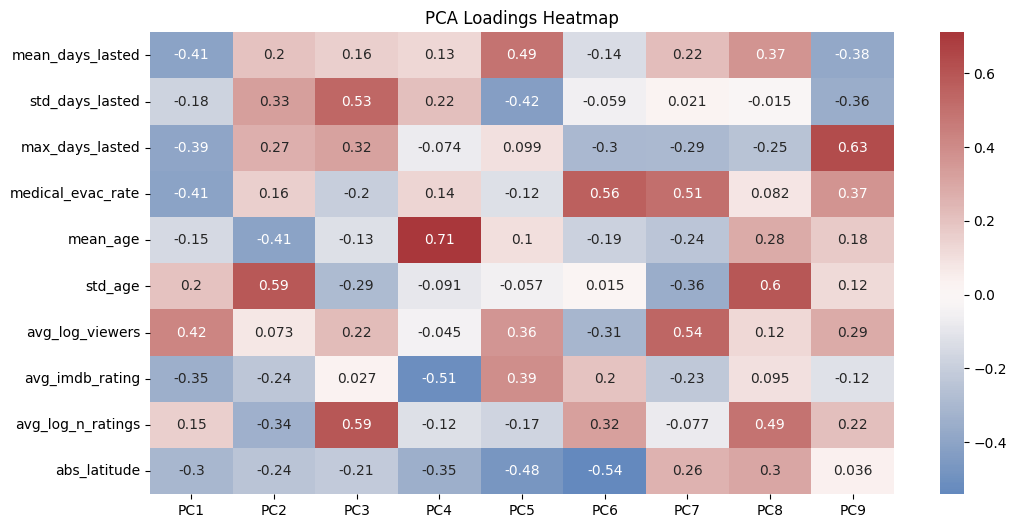

In [ ]:
plt.figure(figsize=(12,6))

sns.heatmap(
    loadings,
    annot=True,
    cmap="vlag",
    center=0)

plt.title("PCA Loadings Heatmap")
plt.show()

#### **3.4.3 Scree Plot - Cumulative Explained Variance**

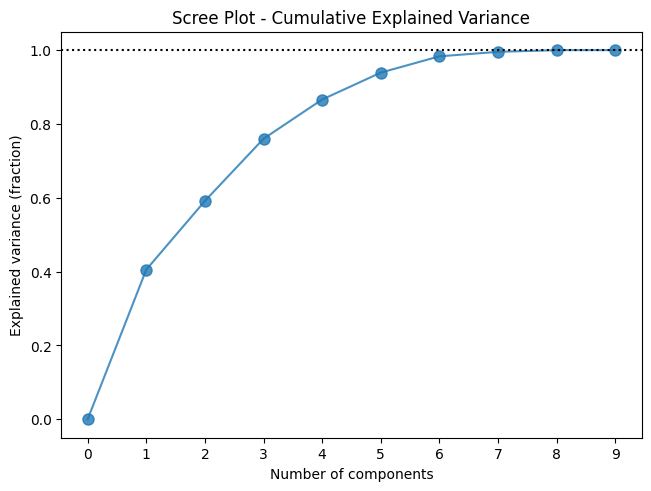

In [ ]:
from psynlig import (
    pca_explained_variance,
    pca_explained_variance_bar,)

_, ax = pca_explained_variance(
    pca,
    marker='o',
    markersize=8,
    alpha=0.8)

ax.set_title("Scree Plot - Cumulative Explained Variance")
plt.show()

#### **3.4.4 Bar Graph - Explained Variance per Principal Component**

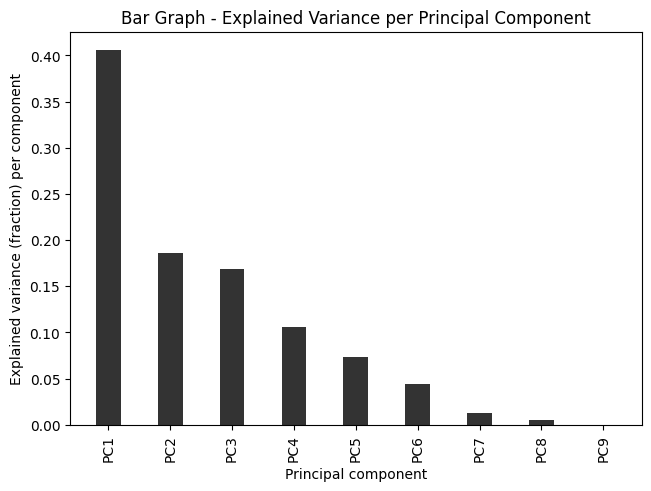

In [ ]:
pca_explained_variance_bar(
    pca,
    width=0.4,
    alpha=0.8,
    color='black')

plt.title("Bar Graph - Explained Variance per Principal Component")
plt.show()

#### **3.4.5 PCA Dimentionality Reduction**

In [ ]:
from sklearn.decomposition import PCA

pca_reduced = PCA(n_components=3)
X_reduced = pca_reduced.fit_transform(X_scaled)

print("Cumulative variance explained (3 PCs):")
print(round(np.sum(pca_reduced.explained_variance_ratio_), 3))

Cumulative variance explained (3 PCs):
0.76


#### **3.4.6 Observation and Interpretation**
PCA and Dimentionsality Reduction

•	The bar graph shows the explained variance for each principal component. PC1 explains about 40% of the total variance, PC2 about 18%, and PC3 about 17%. Together, the first three components explain 76% of the total variance.

•	This indicates that most structural differences between seasons can be captured using just three dimensions instead of using all PCs. The scree plot also shows a clear elbow after PC3, suggesting that additional components contribute limited new information.

•	Therefore, reducing the data to three principal components preserves most of the meaningful variation.

### **3.5 KMeans Clustering - after PCA**

#### **3.5.1 Silhoutte Score and Plot**

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results_pca = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_reduced)
    sil = silhouette_score(X_reduced, labels)
    results_pca.append({"k": k, "silhouette_score": sil})

pd.DataFrame(results_pca)

,k,silhouette_score
0,2,0.206782
1,3,0.260731
2,4,0.332192
3,5,0.257033
4,6,0.153943
5,7,0.071651


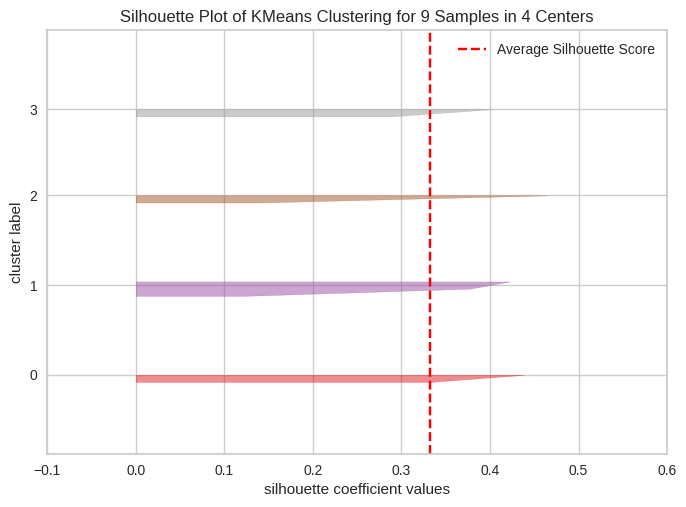

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 9 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer

best_k = 4

model = KMeans(n_clusters=best_k, random_state=42, n_init=10)

visualizer = SilhouetteVisualizer(model)

visualizer.fit(X_reduced)
visualizer.show()

#### **3.5.2 Cluster Summary**

In [ ]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
season_df["cluster"] = kmeans_final.fit_predict(X_reduced)

In [ ]:
cluster_summary = (
    season_df
    .groupby("cluster")
    .agg(count=("season", "count"), seasons=("season", lambda x: sorted(list(x))))
    .reset_index())

cluster_summary

,cluster,count,seasons
0,0,2,"[3, 4]"
1,1,3,"[6, 7, 8]"
2,2,2,"[1, 2]"
3,3,2,"[5, 9]"


#### **3.5.3 Cluster Visualisation on 3D Space**

In [ ]:
import plotly.express as px

plot_df = pd.DataFrame(X_reduced, columns=["PC1", "PC2", "PC3"])

plot_df["season"] = season_df["season"].astype(str)
plot_df["cluster"] = season_df["cluster"].astype(str)

fig = px.scatter_3d(
    plot_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="cluster",
    text="season",
    title="KMeans Clusters on PCA Space")

fig.show()

#### **3.5.4 Observation & Interpretation**
Silhoutte Score and Silhouette Plot

•	The silhouette analysis indicates that the optimal number of clusters is k = 4, as it produces the highest silhouette score (0.33). After k = 4, the score declines, suggesting that additional clusters lead to weaker separation and over-partitioning.

•	A score of 0.33 reflects moderate but meaningful cluster separation, which is reasonable given the small sample size of nine seasons. Also, the silhouette plot shows positive values for all points and relatively balanced cluster widths, indicating that seasons are well grouped within clusters and clearly separated in PCA space.

•	Overall, the results support selecting four clusters, suggesting the presence of four distinct structural season types.


### **3.6 Uniform Manifold Approximation and Projection (UMAP)**

We are applying UMAP as a non-linear dimensionality reduction method to examine whether the clustering structure changes when we move beyond linear approach. The purpose of this step is to test robustness. If the clusters remain similar in UMAP space, it strengthens and validates the findings from the PCA-based analysis.

#### **3.6.1 Fitting UMAP**

In [ ]:
import umap

umap = umap.UMAP(
    n_components=3,
    n_neighbors=5,
    min_dist=0.1,
    metric="euclidean",
    random_state=42)

umap_embeddings = umap.fit_transform(X_scaled)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



#### **3.6.2 UMAP Table**

In [ ]:
umap_df = pd.DataFrame(umap_embeddings, columns=["UMAP1", "UMAP2", "UMAP3"])

umap_df["season"] = season_df["season"].values

umap_df = umap_df[["season", "UMAP1", "UMAP2", "UMAP3"]]

umap_df

,season,UMAP1,UMAP2,UMAP3
0,1,1.733516,23.910532,10.191645
1,2,1.750536,24.268929,10.888756
2,3,2.242359,25.223118,10.877623
3,4,2.670777,24.748913,10.379558
4,5,1.897297,24.633022,9.585026
5,6,0.863544,25.596348,9.876199
6,7,1.233477,25.959911,10.332582
7,8,1.094289,25.085608,10.655871
8,9,1.917468,25.489727,9.521622


**NOTE**

•	Unlike PCA, UMAP does not automatically produce all possible components ranked by explained variance. In UMAP, we must explicitly specify the number of dimensions (n_components).

•	Since my goal was to compare UMAP clustering results with PCA clustering, I selected 3 components, matching the three principal components selected in the PCA analysis.

•	UMAP reduced the standardized season-level feature space into three non-linear embedding dimensions (UMAP1, UMAP2, UMAP3).

•	These dimensions are not linear combinations of the original variables, and they do not have an explained variance measure like PCA. Instead, UMAP preserved the local structure and neighborhood relationships between seasons in a lower-dimensional space.

### **3.7 KMeans Clustering - after UMAP**

####**3.7.1 Silhoutte Score and Plot**

In [ ]:
results_umap = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(umap_embeddings)
    sil = silhouette_score(umap_embeddings, labels)
    results_umap.append({"k": k, "silhouette_score": sil})

pd.DataFrame(results_umap)

,k,silhouette_score
0,2,0.285899
1,3,0.273569
2,4,0.334609
3,5,0.264563
4,6,0.175908
5,7,0.110900


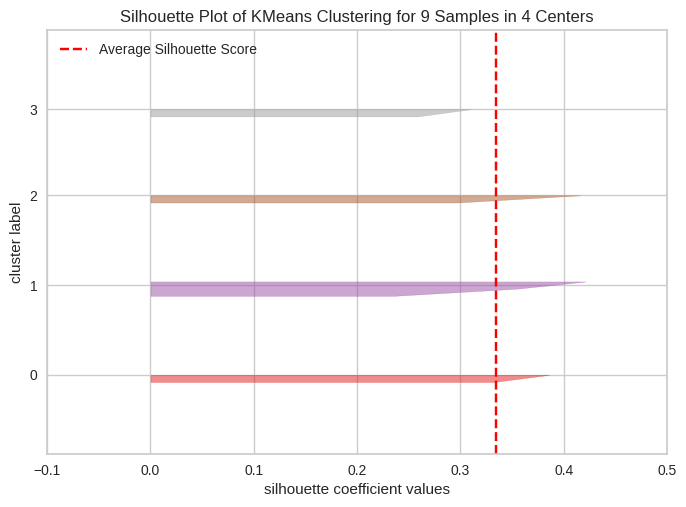

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 9 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
best_k_umap = 4
model = KMeans(n_clusters=best_k_umap, random_state=42, n_init=10)
viz = SilhouetteVisualizer(model)
viz.fit(umap_embeddings)
viz.show()

#### **3.7.2 Cluster Summary**

In [ ]:
best_k_umap = 4

kmeans_umap = KMeans(n_clusters=best_k_umap, random_state=42, n_init=10)
season_df["cluster_umap"] = kmeans_umap.fit_predict(umap_embeddings)

In [ ]:
cluster_summary_umap = (
    season_df
    .groupby("cluster_umap")
    .agg(
        count=("season", "count"),
        seasons=("season", lambda x: sorted(list(x))))
    .reset_index())

cluster_summary_umap

,cluster_umap,count,seasons
0,0,2,"[3, 4]"
1,1,3,"[6, 7, 8]"
2,2,2,"[1, 2]"
3,3,2,"[5, 9]"


#### **3.7.3 Cluster Visualisation on 3D Plane**

In [ ]:
plot_df = pd.DataFrame(umap_embeddings, columns=["UMAP1", "UMAP2", "UMAP3"])

plot_df["season"] = season_df["season"].astype(str)
plot_df["cluster_umap"] = season_df["cluster_umap"].astype(str)

fig = px.scatter_3d(
    plot_df,
    x="UMAP1",
    y="UMAP2",
    z="UMAP3",
    color="cluster_umap",
    text="season",
    title="KMeans Clusters on UMAP Plane")


fig.show()

### **3.8 PCA Vs UMAP**

#### **3.8.1 Silhoutte Score**

Notably, the optimal number of clusters (k = 4, 0.33) is the same in both PCA and UMAP space, indicating consistent structural grouping across both linear and non-linear dimensionality reduction methods.

####**3.8.2 KMeans Clusters**

K-Means clustering in both PCA and UMAP spaces produces the same four clusters with the same season groupings.

This indicates that the underlying relationships between survival duration, medical risk, demography, geography, and audience response are strong enough to persist across different dimensionality reduction approaches.

### **3.9 Cluster Profiling**

In [ ]:
cluster_profile = (season_df.groupby("cluster")[model_features].mean().round(2))

cluster_profile

,mean_days_lasted,std_days_lasted,max_days_lasted,medical_evac_rate,mean_age,std_age,avg_log_viewers,avg_imdb_rating,avg_log_n_ratings,abs_latitude
cluster,,,,,,,,,,
0,42.86,31.62,81.00,0.29,36.21,10.86,0.96,7.56,4.01,45.86
1,45.50,28.72,83.67,0.37,39.43,6.19,0.85,8.05,4.16,58.09
2,28.00,24.26,61.00,0.05,38.50,7.99,1.03,7.63,4.42,50.72
3,38.10,20.53,69.00,0.30,37.30,10.10,0.90,7.97,3.66,54.70


#### **3.9.1 Bar Graph - Cluster Comparison across Features**

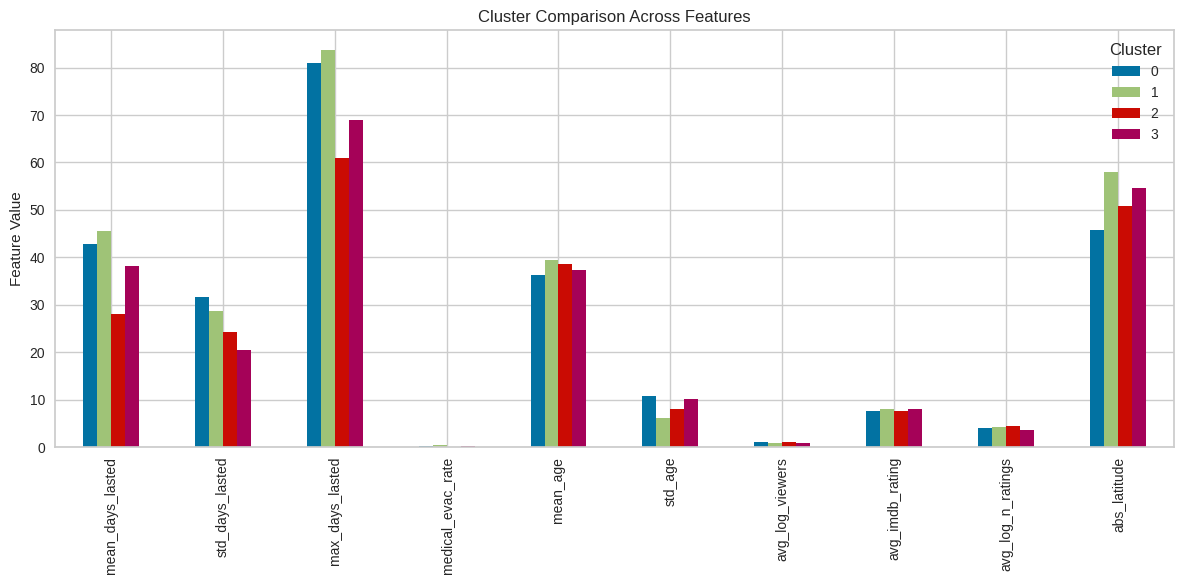

In [ ]:
cluster_profile.T.plot(kind="bar", figsize=(12,6))

plt.title("Cluster Comparison Across Features")
plt.ylabel("Feature Value")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

#### **3.9.2 Observation and Interpretation**
Cluster Profiling

**Cluster 0: Seasons 3 & 4**

•	High Average Survival Days: 42.86 days

•	High Maximum Survival Days: 81.00 days

•	Moderate Medical Evacuation Rate: 29%

•	Lowest Latitude: 45.86

•	Second Highest Average Viewership: 0.96

•	Lowest Average IMDb Rating: 7.56

•	Moderate Rating Volume: 4.01

**Interpretation:**

Cluster 0 represents strong survival seasons that occurred at the lowest latitude among all clusters. Contestants lasted long, but evacuation rates were not extreme. These seasons performed well in viewership but received comparatively lower IMDb ratings. Structurally, they reflect competitive seasons without the most extreme environmental conditions.

**Cluster 1: Seasons 6, 7, 8**

•	Highest Average Survival Days: 45.50 days

•	Highest Maximum Survival Days: 83.67 days

•	Highest Medical Evacuation Rate: 37%

•	Highest Latitude: 58.09

•	Lowest Average Viewership: 0.85

•	Highest Average IMDb Rating: 8.05

•	High Rating Volume: 4.16

**Interpretation:**

Cluster 1 represents the most extreme seasons. They occur at the highest latitude and have both the longest survival durations and the highest evacuation rates. These seasons appear physically demanding. Although viewership is lower, they receive the highest IMDb ratings, suggesting strongest audience appreciation despite lowest audience volume.

**Cluster 2: Seasons 1 & 2**

•	Lowest Average Survival Days: 28.00 days

•	Lowest Maximum Survival Days: 61.00 days

•	Lowest Medical Evacuation Rate: 5%

•	Moderate Latitude: 50.72

•	Highest Average Viewership: 1.03

•	Moderate Average IMDb Rating: 7.63

•	Highest Rating Volume: 4.42

**Interpretation:**

Cluster 2 represents the earliest and least intense seasons. Survival duration was shortest and evacuation rates were very low. However, these seasons achieved the highest viewership and rating volume. This pattern may reflect a novelty effect, where initial seasons attracted greater audience attention despite lower survival intensity compared to later seasons.

**Cluster 3: Seasons 5 & 9**

•	Moderate Average Survival Days: 38.10 days

•	Moderate Maximum Survival Days: 69.00 days

•	High Medical Evacuation Rate: 30%

•	High Latitude: 54.70

•	Moderate Average Viewership: 0.90

•	High Average IMDb Rating: 7.97

•	Lowest Rating Volume: 3.66

**Interpretation:**

Cluster 3 represents moderately intense seasons set in relatively harsh locations. Survival duration is moderate, but higher latitude and evacuation rates indicate physical difficulty. Although rating volume is the lowest, IMDb ratings remain strong. These seasons sit between the early lower-intensity seasons and the most extreme high-latitude cluster.


### **3.10 Conclusion**

Yes, the seasons of Alone can be grouped into distinct types when survival outcomes, contestant characteristics, geography, and audience engagement are analyzed together.

Using season-level aggregation, dimensionality reduction (PCA and UMAP), and K-Means clustering, we find clear evidence that the seasons naturally form four distinct groups.

The clusters can be broadly characterized as:

**Cluster 0 (Seasons 3 & 4) – High Survival, Lower Latitude**

Long survival durations with moderate evacuation rates, occurring at the lowest latitude among all clusters. These seasons reflect strong competitive performance in comparatively milder environments, with steady viewership but comparatively lower IMDb ratings.

**Cluster 1 (Seasons 6, 7 & 8) – Most Extreme, High Latitude**

Longest survival times combined with the highest evacuation rates and highest latitude. These seasons are the most physically demanding and receive the strongest IMDb ratings despite lower overall viewership.

**Cluster 2 (Seasons 1 & 2) – Shorter, Lower Risk, High Engagement**

Shortest survival durations and minimal medical evacuations, yet achieving the highest viewership and rating volume. These seasons reflect lower survival intensity but strong audience attention, likely influenced by novelty.

**Cluster 3 (Seasons 5 & 9) – Moderate Survival, High Latitude**

Moderate survival duration with relatively high latitude and evacuation rates. These seasons show meaningful environmental difficulty and strong IMDb ratings, but lower rating volume, placing them between the early lower-intensity seasons and the most extreme cluster.

#**4. Domain Question 3**
##**Do multidimensional survival difficulty components systematically shape audience size and appreciation, and does a structural trade-off exist between reach and prestige?**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import numpy as np

###**4.1 Additonal Preprocessing**

In [ ]:
def missing_report(df, name):
    m = df.isna().mean().sort_values(ascending=False)
    out = pd.DataFrame({"missing_rate": m, "dtype": df.dtypes}).head(20)
    print( {name} )
    display(out)

missing_report(epi, "episodes")
missing_report(ses, "seasons")
missing_report(sur, "survivalists")
missing_report(load, "loadouts")


{'episodes'}


,missing_rate,dtype
air_date,0.000000,object
author,0.000000,object
episode,0.000000,int64
episode_number_overall,0.000000,int64
imdb_rating,0.051020,float64
n_ratings,0.051020,float64
quote,0.000000,object
season,0.000000,int64
title,0.000000,object
version,0.000000,object


{'seasons'}


,missing_rate,dtype
country,0.000000,object
date_drop_off,0.666667,object
lat,0.000000,float64
location,0.000000,object
lon,0.000000,float64
n_survivors,0.000000,int64
season,0.000000,int64
version,0.000000,object


{'survivalists'}


,missing_rate,dtype
age,0.000000,int64
city,0.000000,object
country,0.000000,object
day_linked_up,0.914894,float64
days_lasted,0.000000,int64
gender,0.000000,object
id,0.000000,object
medically_evacuated,0.000000,bool
name,0.000000,object
profession,0.000000,object


{'loadouts'}


,missing_rate,dtype
version,0.0,object
season,0.0,int64
name,0.0,object
item_number,0.0,int64
item_detailed,0.0,object
item,0.0,object
id,0.0,object


###**4.2 Season Level Aggregate**

In [ ]:

sur_agg = sur.groupby("season").agg(
    n_contestants=("days_lasted", "count"),
    mean_days=("days_lasted", "mean"),
    median_days=("days_lasted", "median"),
    sd_days=("days_lasted", "std"),
    p25_days=("days_lasted", lambda x: np.percentile(x, 25)),
    p75_days=("days_lasted", lambda x: np.percentile(x, 75)),
    med_evac_rate=("medically_evacuated", "mean")
).reset_index()

sur_agg.head()

#Environment Difficulty from seasons csv
season_base = ses[["season", "country", "location", "lat", "lon", "n_survivors"]].copy()
season_base.head()


,season,country,location,lat,lon,n_survivors
0,1,Canada,Quatsino,50.72444,-127.498056,10
1,2,Canada,Quatsino,50.72444,-127.498056,10
2,3,Argentina,Patagonia,-41.00000,-68.000000,10
3,4,Canada,Quatsino,50.72444,-127.498056,14
4,5,Mongolia,Selenge Province,49.75000,106.500000,10


In [ ]:
#Audience response from episodes
epi_agg = epi.groupby("season").agg(
    mean_imdb=("imdb_rating", "mean"),
    sd_imdb=("imdb_rating", "std"),
    mean_viewers=("viewers", "mean"),
    n_episodes=("episode", "count")
).reset_index()

epi_agg.head()

,season,mean_imdb,sd_imdb,mean_viewers,n_episodes
0,1,7.672727,0.214900,1.969700,11
1,2,7.592308,0.155250,1.619077,13
2,3,7.820000,0.139841,1.720400,10
3,4,7.300000,0.244949,1.512200,10
4,5,8.000000,0.149071,1.420400,10


In [ ]:
# Combining all into analysis table
season_df = (
    season_base
    .merge(sur_agg, on="season", how="left")
    .merge(epi_agg, on="season", how="left")
)

season_df.shape
season_df.head()


,season,country,location,lat,lon,n_survivors,n_contestants,mean_days,median_days,sd_days,p25_days,p75_days,med_evac_rate,mean_imdb,sd_imdb,mean_viewers,n_episodes
0,1,Canada,Quatsino,50.72444,-127.498056,10,10,21.600000,7.0,23.566455,4.00,42.00,0.000000,7.672727,0.214900,1.969700,11
1,2,Canada,Quatsino,50.72444,-127.498056,10,10,34.400000,28.0,24.954180,11.25,58.50,0.100000,7.592308,0.155250,1.619077,13
2,3,Argentina,Patagonia,-41.00000,-68.000000,10,10,54.300000,61.5,30.861879,39.00,76.75,0.300000,7.820000,0.139841,1.720400,10
3,4,Canada,Quatsino,50.72444,-127.498056,14,14,31.428571,14.0,32.376901,2.75,67.75,0.285714,7.300000,0.244949,1.512200,10
4,5,Mongolia,Selenge Province,49.75000,106.500000,10,10,30.100000,31.5,19.416202,12.75,39.75,0.300000,8.000000,0.149071,1.420400,10


In [ ]:
season_df[["mean_days","med_evac_rate","lat","lon","mean_imdb","mean_viewers"]].describe()

,mean_days,med_evac_rate,lat,lon,mean_imdb,mean_viewers
count,9.000000,9.000000,9.000000,9.000000,9.000000,8.000000
mean,39.380952,0.265079,43.872283,-84.480000,7.828304,1.529361
std,10.655165,0.141080,32.218259,75.840033,0.294941,0.238333
min,21.600000,0.000000,-41.000000,-127.498056,7.300000,1.224545
25%,31.428571,0.285714,50.724440,-127.498056,7.672727,1.392005
50%,41.200000,0.300000,50.724440,-114.001111,7.820000,1.486975
75%,46.100000,0.300000,59.660000,-68.000000,8.000000,1.644408
max,54.300000,0.500000,61.500278,106.500000,8.336364,1.969700


<Axes: >

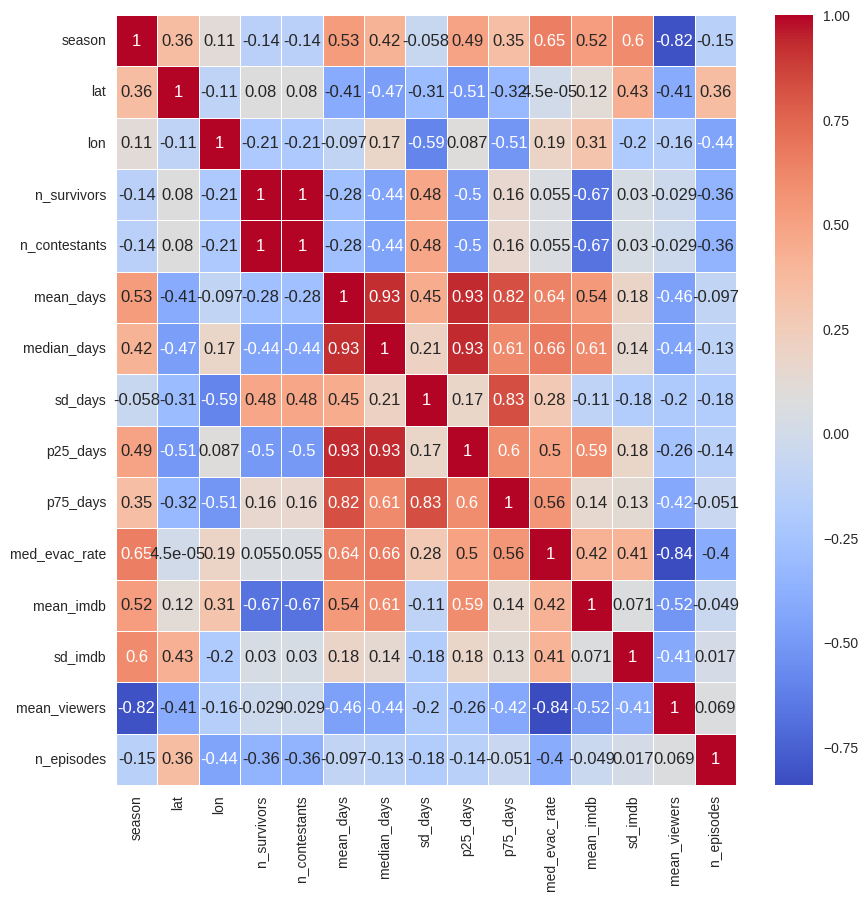

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(season_df.corr(numeric_only=True), annot = True,cmap="coolwarm",linewidths=0.5, ax = ax)

###**4.3 Standardizing**

In [ ]:
difficulty_features = [
    "mean_days","median_days","sd_days",
    "p25_days","p75_days",
    "med_evac_rate",
    "lat","lon"
]

X = season_df[difficulty_features]

#Impute
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X_imp = SimpleImputer(strategy="median").fit_transform(X)
X_scaled = StandardScaler().fit_transform(X_imp)


###**4.4 Checking Variance**

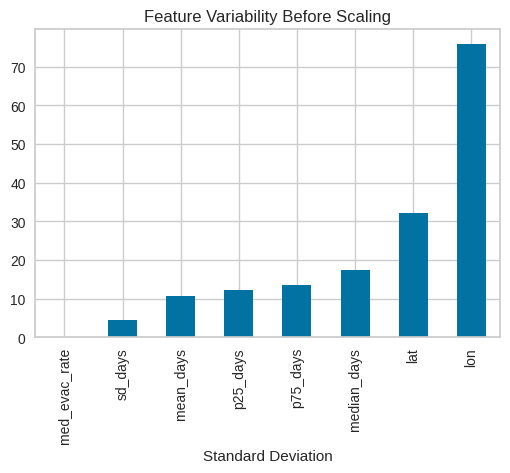

In [ ]:
season_df[difficulty_features].var()
season_df[difficulty_features].std()
season_df[difficulty_features].std().sort_values().plot(
    kind="bar", figsize=(6,4),
    title="Feature Variability Before Scaling"
)
plt.xlabel("Standard Deviation")
plt.show()


###**4.5 PCA**

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=4)
Z = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_

pd.DataFrame(
    pca.components_.T,
    index=difficulty_features,
    columns=[f"PC{i+1}" for i in range(4)]
).sort_values("PC1", ascending=False)


,PC1,PC2,PC3,PC4
mean_days,0.465898,0.061723,0.051357,-0.236420
median_days,0.431803,0.275816,0.011007,-0.150554
p75_days,0.420257,-0.329211,0.093521,0.048614
p25_days,0.420221,0.244066,-0.118133,-0.402632
med_evac_rate,0.323828,0.158882,0.590223,0.439741
sd_days,0.273929,-0.525648,-0.063247,0.470835
lon,-0.065907,0.663834,0.007591,0.472520
lat,-0.242977,-0.099711,0.788745,-0.344426


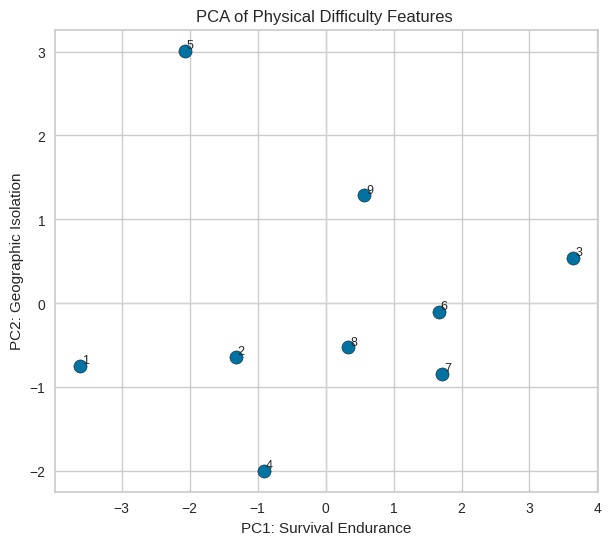

In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(Z[:,0], Z[:,1], s=90, edgecolor="black")

for i, s in enumerate(season_df["season"]):
    plt.text(Z[i,0]+0.03, Z[i,1]+0.03, str(s), fontsize=9)

plt.xlabel("PC1: Survival Endurance")
plt.ylabel("PC2: Geographic Isolation")
plt.title("PCA of Physical Difficulty Features ")
plt.axhline(0, color="lightgray", lw=1)
plt.axvline(0, color="lightgray", lw=1)
plt.show()


###**4.6 K-Means Clustering**

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2,6):
    km = KMeans(n_clusters=k, n_init=50, random_state=42)
    labels = km.fit_predict(Z[:, :2])
    sil = silhouette_score(Z[:, :2], labels)
    print(f"k={k}, silhouette={sil:.3f}")

season_df["difficulty_cluster"] = KMeans(
    n_clusters=3, n_init=50, random_state=42
).fit_predict(Z[:, :2])


k=2, silhouette=0.354
k=3, silhouette=0.360
k=4, silhouette=0.262
k=5, silhouette=0.236


###**4.7 Elbow Method**

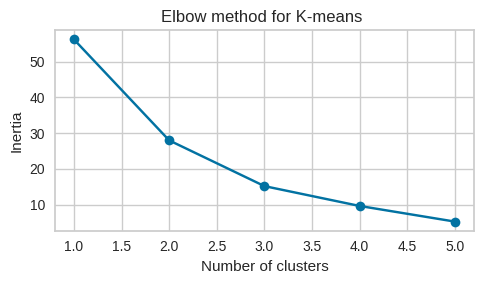

In [ ]:
# Validating the choice of k using Elbow Method as prof taught in class
from sklearn.cluster import KMeans
inertias = []
Ks = range(1, 6)

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(Z[:, :2])
    inertias.append(km.inertia_)

plt.figure(figsize=(5,3))
plt.plot(Ks, inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow method for K-means ')
plt.tight_layout()
plt.show()

###**4.8 Checking Clusters with original features**

In [ ]:
difficulty_features = [
    "mean_days","median_days","p25_days","p75_days","sd_days",
    "med_evac_rate","lat","lon"
]

cluster_summary = season_df.groupby("difficulty_cluster")[difficulty_features].mean()
cluster_summary


,mean_days,median_days,p25_days,p75_days,sd_days,med_evac_rate,lat,lon
difficulty_cluster,,,,,,,,
0,47.380000,46.100000,27.95,70.250000,27.733534,0.340000,38.585445,-96.865167
1,29.142857,16.333333,6.00,56.083333,26.965845,0.128571,50.724440,-127.498056
2,30.100000,31.500000,12.75,39.750000,19.416202,0.300000,49.750000,106.500000


###**4.9 Comparing clusters to Audience Response**

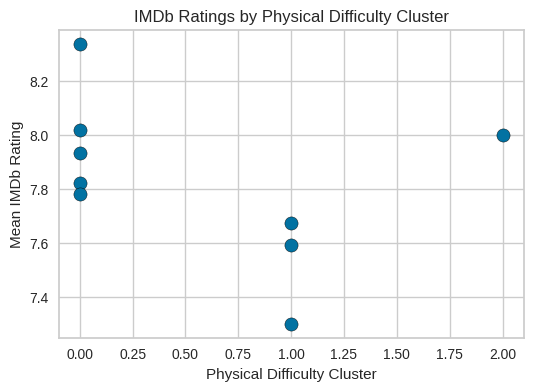

In [ ]:
plt.figure(figsize=(6,4))
x = season_df["difficulty_cluster"]
plt.scatter(
    x,
    season_df["mean_imdb"],
    s=90,
    edgecolor="black"
)

plt.xlabel("Physical Difficulty Cluster")
plt.ylabel("Mean IMDb Rating")
plt.title("IMDb Ratings by Physical Difficulty Cluster")
plt.show()


In [ ]:
# A comprehensive summary for clear understandng
cluster_audience_summary = season_df.groupby('difficulty_cluster').agg({
    'season': 'count',
    'mean_imdb': ['mean', 'std'],
    'mean_viewers': ['mean', 'std'],
    'mean_days': 'mean',
    'med_evac_rate': 'mean',
    'lat': 'mean',
    'lon': 'mean'
}).round(2)

# column names
cluster_audience_summary.columns = [
    'n_seasons',
    'imdb_mean', 'imdb_std',
    'viewers_mean', 'viewers_std',
    'avg_survival_days', 'med_evac_rate',
    'avg_latitude', 'avg_longitude'
]

print("="*80)
print("CLUSTER PROFILES: Difficulty + Audience Response")
print("="*80)
print(cluster_audience_summary)

# Add interpretive labels
cluster_labels = {
    0: "High Endurance / High Risk",
    1: "Moderate Difficulty / Accessible",
    2: "Geographic Novelty / Mixed Risk"
}

print("\n" + "="*80)
print("CLUSTER INTERPRETATIONS")
print("="*80)
for i in range(3):
    print(f"\nCluster {i}: {cluster_labels.get(i, 'Unknown')}")
    n = cluster_audience_summary.loc[i, 'n_seasons']
    imdb = cluster_audience_summary.loc[i, 'imdb_mean']
    viewers = cluster_audience_summary.loc[i, 'viewers_mean']
    days = cluster_audience_summary.loc[i, 'avg_survival_days']
    evac = cluster_audience_summary.loc[i, 'med_evac_rate']
    print(f"  • {n:.0f} seasons")
    print(f"  • IMDb: {imdb:.2f} ± {cluster_audience_summary.loc[i, 'imdb_std']:.2f}")
    print(f"  • Viewers: {viewers:.2f}M ± {cluster_audience_summary.loc[i, 'viewers_std']:.2f}M")
    print(f"  • Avg survival: {days:.1f} days")
    print(f"  • Med evac rate: {evac:.1%}")

CLUSTER PROFILES: Difficulty + Audience Response
                    n_seasons  imdb_mean  imdb_std  viewers_mean  viewers_std  \
difficulty_cluster                                                              
0                           5       7.98      0.22          1.43         0.22   
1                           3       7.52      0.20          1.70         0.24   
2                           1       8.00       NaN          1.42          NaN   

                    avg_survival_days  med_evac_rate  avg_latitude  \
difficulty_cluster                                                   
0                               47.38           0.34         38.59   
1                               29.14           0.13         50.72   
2                               30.10           0.30         49.75   

                    avg_longitude  
difficulty_cluster                 
0                          -96.87  
1                         -127.50  
2                          106.50  

CLUSTER INTER

###**4.10 Hierarchical Clustering**

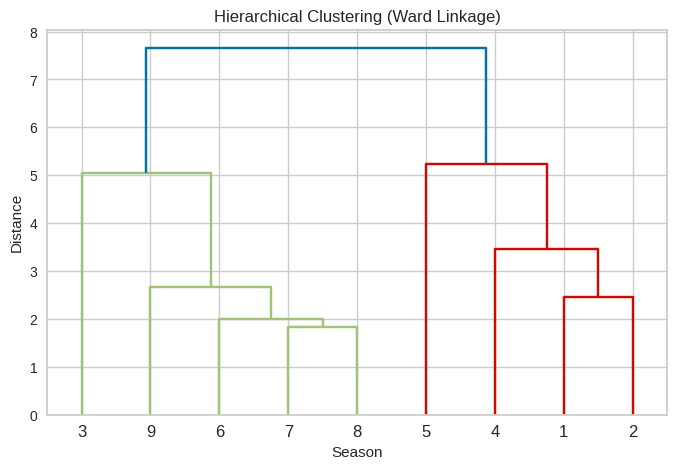

,season,hier_cluster_3
0,1,2
1,2,2
2,3,1
3,4,2
4,5,3
5,6,1
6,7,1
7,8,1
8,9,1


In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

Z_ward = linkage(X_scaled, method='ward')

plt.figure(figsize=(8,5))
dendrogram(Z_ward, labels=season_df['season'].values)
plt.title("Hierarchical Clustering (Ward Linkage)")
plt.xlabel("Season")
plt.ylabel("Distance")
plt.show()

season_df["hier_cluster_3"] = fcluster(Z_ward, 3, criterion='maxclust')

season_df[["season", "hier_cluster_3"]]


In [ ]:
#Overlap btewn k means and hierarchical
pd.crosstab(season_df["difficulty_cluster"],
            season_df["hier_cluster_3"])


hier_cluster_3,1,2,3
difficulty_cluster,,,
0,5,0,0
1,0,3,0
2,0,0,1


####**4.10.1 Silhoutte Score**

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

seeds = range(30)
sil_scores = []

for seed in seeds:
    kmeans = KMeans(n_clusters=3, random_state=seed, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

print("Mean Silhouette Score:", np.mean(sil_scores))
print("Std Dev Silhouette Score:", np.std(sil_scores))
print("Min Silhouette Score:", np.min(sil_scores))
print("Max Silhouette Score:", np.max(sil_scores))

Mean Silhouette Score: 0.24718227929744904
Std Dev Silhouette Score: 0.012319258528772782
Min Silhouette Score: 0.20280535914657818
Max Silhouette Score: 0.25187628762625053


###**4.11 Regression-based quantification of the trade-off**

This will help me assess are these difficulty clusters actually influencing ratings or viewerships

In [ ]:
season_df["PC1"] = Z[:, 0]
season_df["PC2"] = Z[:, 1]
season_df["PC3"] = Z[:, 2]

season_df[["season", "PC1", "PC2", "PC3", "mean_imdb", "mean_viewers"]]

,season,PC1,PC2,PC3,mean_imdb,mean_viewers
0,1,-3.615710,-0.740857,-1.064091,7.672727,1.969700
1,2,-1.324036,-0.633169,-0.513611,7.592308,1.619077
2,3,3.641963,0.538094,-2.113520,7.820000,1.720400
3,4,-0.909909,-1.992763,0.332055,7.300000,1.512200
4,5,-2.071752,3.009427,0.281423,8.000000,1.420400
5,6,1.661133,-0.099200,1.550105,8.018182,1.224545
6,7,1.714821,-0.843528,0.609455,8.336364,1.306818
7,8,0.334735,-0.524175,0.372618,7.781818,1.461750
8,9,0.568754,1.286171,0.545567,7.933333,NaN


In [ ]:
import statsmodels.api as sm

X_reg = season_df[["PC1", "PC2", "PC3"]]
X_reg = sm.add_constant(X_reg)

# IMDb model
y_imdb = season_df["mean_imdb"]
model_imdb = sm.OLS(y_imdb, X_reg).fit()
print(model_imdb.summary())

# Viewership model
viewers_df = season_df.dropna(subset=["mean_viewers"])

X_reg_v = viewers_df[["PC1", "PC2", "PC3"]]
X_reg_v = sm.add_constant(X_reg_v)

y_viewers = viewers_df["mean_viewers"]

model_viewers = sm.OLS(y_viewers, X_reg_v).fit()
print(model_viewers.summary())



                            OLS Regression Results                            
Dep. Variable:              mean_imdb   R-squared:                       0.483
Model:                            OLS   Adj. R-squared:                  0.173
Method:                 Least Squares   F-statistic:                     1.559
Date:                Wed, 04 Mar 2026   Prob (F-statistic):              0.309
Time:                        02:18:14   Log-Likelihood:                 1.7201
No. Observations:                   9   AIC:                             4.560
Df Residuals:                       5   BIC:                             5.349
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.8283      0.089     87.578      0.0

###**4.12 Conclusion:**

Across multiple validation steps, a consistent pattern emerges: survival difficulty in Alone is multidimensional, structurally stable, and systematically linked to a trade-off between audience reach and audience appreciation. Difficulty cannot be reduced to geography alone. Instead, realized survival intensity, how long contestants last, how variable outcomes are, and how frequently medical evacuations occur, plays a central role in shaping the character of a season.

Seasons naturally group into three stable difficulty profiles, and this structure remains consistent across clustering methods and random initializations. These profiles align meaningfully with audience response. Endurance-heavy, higher-risk seasons tend to receive stronger IMDb ratings but attract smaller average audiences, while more moderate seasons reach broader audiences but are rated less favorably.

This reveals a clear reach-versus-prestige trade-off embedded in the data. Increasing survival intensity appears to deepen appreciation among a smaller, more engaged audience, while reducing intensity broadens appeal but slightly weakens perceived quality. Rather than asking whether harsher locations attract more viewers, the more strategic question becomes: how much reach is the show willing to trade for perceived intensity and prestige? The findings suggest that survival difficulty shapes not only contestant experience but also how audiences evaluate and engage with the show.

# **5. Domain Question 4**
##**Do seasons that appear “harder” for contestants systematically receive more or fewer viewers and higher or lower IMDb ratings, and what does this reveal about how audience engagement responds to perceived difficulty and risk in Alone?**

## **5.1 Season Level Summary Table related to the domain question**

In [ ]:

for _df in [sur, epi, ses, load]:
    if 'version' not in _df.columns:
        _df['version'] = 'US'
if 'id' not in sur.columns:
    sur = sur.copy()
    sur['id'] = sur['name']

if 'id' not in load.columns:
    load = load.copy()
    load['id'] = load['name']
for _df in [epi, ses, sur, load]:
    if 'version' not in _df.columns:
        _df['version'] = 'US'
if 'id' not in sur.columns:
    sur = sur.copy()
    sur['id'] = sur['name']  # fallback to name as unique identifier

if 'id' not in load.columns:
    load = load.copy()
    load['id'] = load['name']  # fallback for loadouts
df = (
    sur.merge(
        ses[['version','season','location','lat','lon','date_drop_off']],
        on=['version','season'],
        how='left'
    )
    .groupby(['version','season','id','name'], as_index=False)
    .agg({
        'age': 'first',
        'gender': 'first',
        'profession': 'first',
        'city': 'first',
        'state': 'first',
        'country': 'first',
        'days_lasted': 'max',
        'result': 'first',
        'medically_evacuated': 'first',
        'reason_category': 'first',
        'location': 'first',
        'lat': 'first',
        'lon': 'first',
        'date_drop_off': 'first',
        'team':'first'
    })
)
assert df[['version','season','id']].duplicated().sum() == 0
epi_season = (
    epi.groupby(['version','season'], as_index=False)
       .agg({
           'viewers': 'mean',
           'imdb_rating': 'mean',
           'n_ratings': 'mean'
       })
)
df = df.merge(
    epi_season,
    on=['version','season'],
    how='left'
)
load_person = (
    load[['version','season','id','item','item_detailed']]
    .drop_duplicates()
    .groupby(['version','season','id'], as_index=False)
    .agg({'item': list, 'item_detailed' : list})
)

df = df.merge(
    load_person,
    on=['version','season','id'],
    how='left'
)
df

,version,season,id,name,age,gender,profession,city,state,country,...,location,lat,lon,date_drop_off,team,viewers,imdb_rating,n_ratings,item,item_detailed
0,US,1,Alan Kay,Alan Kay,40,Male,Corrections Officer,Blairsville,Georgia,United States,...,Quatsino,50.72444,-127.498056,None,None,1.9697,7.672727,101.545455,"[Saw, Axe, Sleeping bag, Pot, Ferro rod, Cante...","[Saw, Axe, Sleeping bag, Large 2-quart pot, Fe..."
1,US,1,Brant McGee,Brant McGee,44,Male,US Army Guard and Former US Coast Guard,Albemarle,North Carolina,United States,...,Quatsino,50.72444,-127.498056,None,None,1.9697,7.672727,101.545455,"[Tarp, Paracord, Axe, Sleeping bag, Pot, Ferro...","[12×12 ground sheet tarp, 550 paracord – 20m, ..."
2,US,1,Chris Weatherman,Chris Weatherman,41,Male,Author,Umatilla,Florida,United States,...,Quatsino,50.72444,-127.498056,None,None,1.9697,7.672727,101.545455,"[Saw, Axe, Sleeping bag, Ferro rod, Pot, Cante...","[Saw, Axe, Sleeping bag, Ferro rod, Large 2 qu..."
3,US,1,Dustin Feher,Dustin Feher,37,Male,Carpenter,Pittsburgh,Pennsylvania,United States,...,Quatsino,50.72444,-127.498056,None,None,1.9697,7.672727,101.545455,"[Paracord, Axe, Sleeping bag, Pot, Ferro rod, ...","[550 paracord – 20m, Axe, Sleeping bag, Large ..."
4,US,1,Joe Robinet,Joe Robinet,24,Male,Carpenter,Windsor,Ontario,Canada,...,Quatsino,50.72444,-127.498056,None,None,1.9697,7.672727,101.545455,"[Tarp, Paracord, Axe, Sleeping bag, Pot, Ferro...","[12x 12 tarp, 550 paracord – 20m, Axe, Sleepin..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,US,9,Juan Pablo Quinonez,Juan Pablo Quinonez,30,Male,Outdoor Professional,Pinawa,Manitoba,Canada,...,Nunatsiavut,59.66000,-64.273611,2021-09-18,None,NaN,7.933333,27.666667,"[Ferro rod, Paracord, Pot, Axe, Fishing gear, ...","[Ferro rod, Paracord, 2-quart pot, Axe, Fishin..."
90,US,9,Karie Lee Knoke,Karie Lee Knoke,57,Female,Wilderness/Primitive Skills Instructor,Sandpoint,Idaho,United States,...,Nunatsiavut,59.66000,-64.273611,2021-09-18,None,NaN,7.933333,27.666667,"[Paracord, Sleeping bag, Pot, Ferro rod, Fishi...","[Paracord, Sleeping bag, 2-quart pot, Ferro ro..."
91,US,9,Teimojin Tan,Teimojin Tan,31,Male,Physician,Montreal,Quebec,Canada,...,Nunatsiavut,59.66000,-64.273611,2021-09-18,None,NaN,7.933333,27.666667,"[Sleeping bag, Axe, Multitool, Ferro rod, Pot,...","[Sleeping bag, Axe, Multitool, Ferro rod, 2-qu..."
92,US,9,Terry Burns,Terry Burns,30,Male,Commercial Fisherman,Homer,Alaska,United States,...,Nunatsiavut,59.66000,-64.273611,2021-09-18,None,NaN,7.933333,27.666667,"[Axe, Sleeping bag, Bow and arrows, Fishing ge...","[Axe, Sleeping bag, Bow and arrows, Fishing li..."


In [ ]:
#Dropping irrelevant columns
df_clean = df.drop(columns=[
    "id",
    "name",
    "city",
    "state",
    "date_drop_off",
    "team",
    "version",
    "item_detailed",
]).copy()
#Missing Report
missing_count = df_clean.isna().sum().sort_values(ascending=False)
missing_pct = (missing_count / len(df_clean)).round(3)

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct})

In [ ]:
# Replacing missing exit reasons with "Unknown"
df_clean["reason_category"] = df_clean["reason_category"].fillna("Unknown")
# First, imputing missing viewers using the median within each season
df_clean["viewers"] = df_clean["viewers"].fillna(df_clean.groupby("season")["viewers"].transform("median"))

# Then, filling an entire season 9 missing value with the overall median
df_clean["viewers"] = df_clean["viewers"].fillna(df_clean["viewers"].median())
# Converting the list of items to a hashable representation
df_clean["item"] = df_clean["item"].apply(tuple)

In [ ]:
#Selecting numeric variables
num_vars = [
    "lon",
    "viewers",
    "n_ratings",
    "days_lasted",
    "age",
    "imdb_rating",
    "lat"]

# Computing skewness
df_clean[num_vars].skew().sort_values(ascending=False)


,0
lon,2.113712
viewers,0.684702
n_ratings,0.583941
days_lasted,0.176316
age,0.019834
imdb_rating,-0.108219
lat,-2.470944


In [ ]:
# Creating log versions
df_clean["log_viewers"] = np.log1p(df_clean["viewers"])
df_clean["log_n_ratings"] = np.log1p(df_clean["n_ratings"])

# Dropping raw skewed versions
df_clean = df_clean.drop(columns=["viewers", "n_ratings"])

In [ ]:
# Defining Categorical Variables
categorical_cols = [
    "gender",
    "profession",
    "country",
    "reason_category",
    "location",
    "season",
    "result",
    "item",
    "medically_evacuated"]

# Converting it to 'category' dtype
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype("category")

# Defining the numeric variables
numeric_cols = df_clean.select_dtypes(include=["int64","float64"]).columns
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   season               94 non-null     category
 1   age                  94 non-null     int64   
 2   gender               94 non-null     category
 3   profession           94 non-null     category
 4   country              94 non-null     category
 5   days_lasted          94 non-null     int64   
 6   result               94 non-null     category
 7   medically_evacuated  94 non-null     category
 8   reason_category      94 non-null     category
 9   location             94 non-null     category
 10  lat                  94 non-null     float64 
 11  lon                  94 non-null     float64 
 12  imdb_rating          94 non-null     float64 
 13  item                 94 non-null     category
 14  log_viewers          94 non-null     float64 
 15  log_n_ratings        94 n

In [ ]:
# season-level summary from df_clean
season_summary = (
    df_clean
    .groupby('season', as_index=False)
    .agg(
        n_contestants      = ('days_lasted','size'),
        mean_days_lasted   = ('days_lasted','mean'),
        median_days_lasted = ('days_lasted','median'),
        early_exit_rate    = ('days_lasted', lambda s: (s < 20).mean()),
        med_evacuated_rate = ('medically_evacuated', lambda s: (s == 'True').mean()),
        mean_imdb_rating   = ('imdb_rating','mean'),
        mean_log_viewers   = ('log_viewers','mean'),
        mean_log_nratings  = ('log_n_ratings','mean')
    )
)

/tmp/ipykernel_1061/447030816.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
import numpy as np

# helper flags on df_clean
df_clean = df_clean.copy()
df_clean['female_flag'] = (df_clean['gender'] == 'Female').astype(int)
df_clean['winner_flag'] = (df_clean['result'] == 1).astype(int)

season_features = (
    df_clean
    .groupby('season', as_index=False)
    .agg(
        n_contestants      = ('days_lasted','size'),
        mean_days_lasted   = ('days_lasted','mean'),
        median_days_lasted = ('days_lasted','median'),
        early_exit_rate    = ('days_lasted', lambda s: (s < 20).mean()),
        # medically_evacuated is category; treat 'True' as evacuated
        med_evacuated_rate = ('medically_evacuated', lambda s: (s == 'True').mean()),
        mean_imdb_rating   = ('imdb_rating','mean'),
        mean_log_viewers   = ('log_viewers','mean'),
        mean_log_nratings  = ('log_n_ratings','mean'),
        median_age_season  = ('age','median'),
        share_female       = ('female_flag','mean'),
        winner_days        = ('days_lasted','max')
    )
)

season_features['spread_days'] = (
    season_features['winner_days'] - season_features['median_days_lasted']
)
season_features = season_features.sort_values('season')



/tmp/ipykernel_1061/3900662168.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
# reason composition per season
reason_counts = (
    df_clean
    .groupby(['season','reason_category'])
    .size()
    .reset_index(name='count')
)

reason_counts['share'] = reason_counts.groupby('season')['count'].transform(
    lambda x: x / x.sum()
)

reason_wide = (
    reason_counts
    .pivot(index='season', columns='reason_category', values='share')
    .reset_index()
)

reason_wide = reason_wide.rename(columns={
    'Family / personal': 'share_family',
    'Medical / health': 'share_medical',
    'Loss of inventory': 'share_inventory'
})

season_features = season_features.merge(reason_wide, on='season', how='left')
season_features = season_features.round(3)
season_features


/tmp/ipykernel_1061/3366149826.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1061/3366149826.py:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,season,n_contestants,mean_days_lasted,median_days_lasted,early_exit_rate,med_evacuated_rate,mean_imdb_rating,mean_log_viewers,mean_log_nratings,median_age_season,share_female,winner_days,spread_days,share_family,share_inventory,share_medical,Unknown
0,1,10,21.600,7.0,0.600,0.0,7.673,1.088,4.630,35.5,0.000,56,49.0,0.700,0.1,0.100,0.100
1,2,10,34.400,28.0,0.300,0.0,7.592,0.963,4.216,44.0,0.300,66,38.0,0.600,0.0,0.300,0.100
2,3,10,54.300,61.5,0.200,0.0,7.820,1.001,4.130,36.5,0.300,87,25.5,0.400,0.0,0.500,0.100
3,4,14,31.429,14.0,0.571,0.0,7.300,0.921,3.890,34.0,0.071,75,61.0,0.571,0.0,0.286,0.143
4,5,10,30.100,31.5,0.300,0.0,8.000,0.884,3.959,36.5,0.300,60,28.5,0.500,0.0,0.400,0.100
5,6,10,45.400,50.0,0.300,0.0,8.018,0.800,4.093,39.0,0.300,77,27.0,0.200,0.1,0.600,0.100
6,7,10,49.900,44.0,0.200,0.0,8.336,0.836,4.316,33.5,0.200,100,56.0,0.000,0.1,0.800,0.100
7,8,10,41.200,30.5,0.200,0.0,7.782,0.901,4.073,42.5,0.300,74,43.5,0.200,0.0,0.700,0.100
8,9,10,46.100,44.5,0.100,0.0,7.933,0.921,3.356,35.5,0.200,78,33.5,0.200,0.0,0.700,0.100


In [ ]:
reason_counts = (
    df_clean
    .groupby(['season','reason_category'], observed=False)
    .size()
    .reset_index(name='count')
)

reason_counts['share'] = reason_counts.groupby('season', observed=False)['count'].transform(
    lambda x: x / x.sum()
)


In [ ]:
from sklearn.preprocessing import StandardScaler

hard_cols = ['mean_days_lasted','early_exit_rate','med_evacuated_rate']
scaler = StandardScaler()
H = scaler.fit_transform(season_features[hard_cols])

# longer stays and more med_evacs = harder, more early exits = easier
season_features['hardness_index'] = (
    0.5 * H[:,0]      # mean_days_lasted
    - 0.3 * H[:,1]    # early_exit_rate
    + 0.2 * H[:,2]    # med_evacuated_rate
)
season_features['rating_minus_viewers'] = (
    season_features['mean_imdb_rating'] - season_features['mean_log_viewers']
)

In [ ]:
eda_cols = ['mean_days_lasted', 'early_exit_rate', 'mean_imdb_rating',
            'mean_log_viewers', 'mean_log_nratings', 'hardness_index']

corr = season_features[eda_cols].corr().round(2)
corr


,mean_days_lasted,early_exit_rate,mean_imdb_rating,mean_log_viewers,mean_log_nratings,hardness_index
mean_days_lasted,1.00,-0.79,0.54,-0.45,-0.32,0.97
early_exit_rate,-0.79,1.00,-0.64,0.44,0.49,-0.92
mean_imdb_rating,0.54,-0.64,1.00,-0.53,0.01,0.60
mean_log_viewers,-0.45,0.44,-0.53,1.00,0.36,-0.47
mean_log_nratings,-0.32,0.49,0.01,0.36,1.00,-0.40
hardness_index,0.97,-0.92,0.60,-0.47,-0.40,1.00


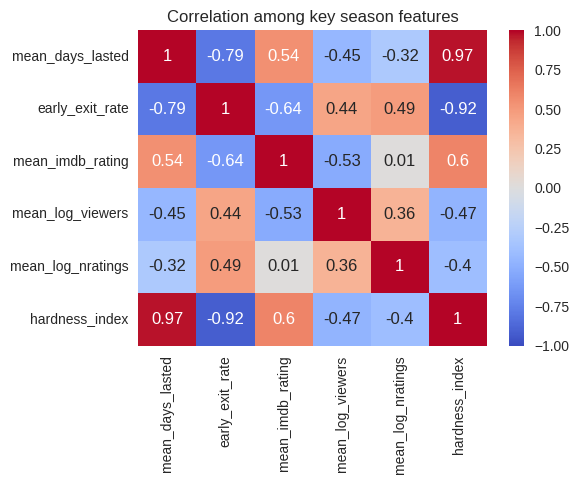

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation among key season features')
plt.tight_layout()
plt.show()


## **5.2 PCA And Dimensionality Reduction**

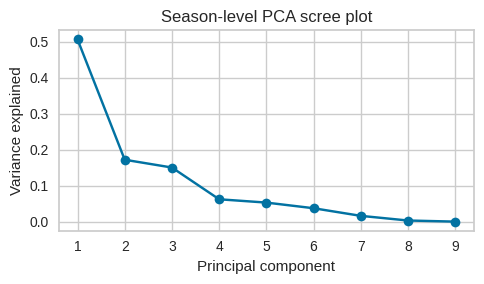

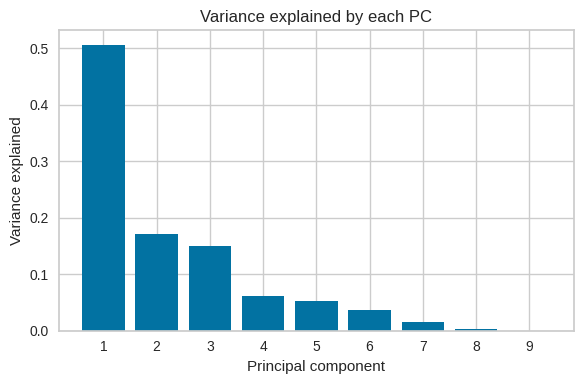

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# numeric columns only, keep one set of share_* columns
num_cols = season_features.select_dtypes(include=['float64','int64']).columns.tolist()
num_cols = [c for c in num_cols if not c.endswith('_y')]  # drop *_y duplicates

X = season_features[num_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pcs = pca.fit_transform(X_scaled)

# scree plot – use n_components from pca
n_comp = len(pca.explained_variance_ratio_)

plt.figure(figsize=(5,3))
plt.plot(range(1, n_comp + 1),
         pca.explained_variance_ratio_,
         marker='o')
plt.xlabel('Principal component')
plt.ylabel('Variance explained')
plt.title('Season-level PCA scree plot')
plt.tight_layout()
plt.show()

# attach first two PCs
season_features['PC1'] = X_pcs[:, 0]
season_features['PC2'] = X_pcs[:, 1]

season_features[['season','PC1','PC2']]
import matplotlib.pyplot as plt
import numpy as np

# assuming pca is already fitted
var_ratio = pca.explained_variance_ratio_
n_comp = len(var_ratio)

plt.figure(figsize=(6,4))
plt.bar(range(1, n_comp + 1), var_ratio)
plt.xlabel('Principal component')
plt.ylabel('Variance explained')
plt.title('Variance explained by each PC')
plt.xticks(range(1, n_comp + 1))
plt.tight_layout()
plt.show()


In [ ]:
# loadings matrix: features x components
loadings = pd.DataFrame(
    pca.components_.T,
    index=num_cols,
    columns=[f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))]
)
var_ratio = pca.explained_variance_ratio_

pc1_pct = var_ratio[0] * 100
pc2_pct = var_ratio[1] * 100
pc3_pct = var_ratio[2] * 100
cum_123_pct = np.sum(var_ratio[:3]) * 100

pc1_pct, pc2_pct, pc3_pct, cum_123_pct

(np.float64(50.63732859022255),
 np.float64(17.19936875601069),
 np.float64(15.033130049642365),
 np.float64(82.8698273958756))

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_reduced = pca.fit_transform(X_scaled)

# optional: attach to season_features
season_features['PC1'] = X_reduced[:, 0]
season_features['PC2'] = X_reduced[:, 1]
season_features['PC3'] = X_reduced[:, 2]

## **5.3 K Means Clustering**

### **5.3.1 Elbow Method**

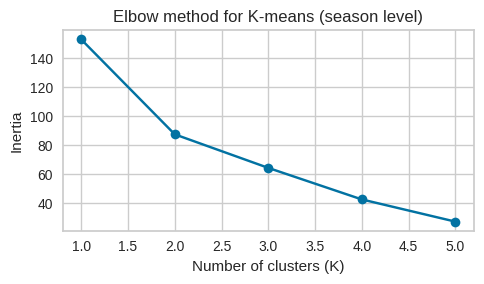

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# X_scaled from your PCA step
inertias = []
Ks = range(1, 6)

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(5,3))
plt.plot(Ks, inertias, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow method for K-means (season level)')
plt.tight_layout()
plt.show()


### **5.3.2 Silhouette Score**

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

Ks = range(2, 5)
sil_scores = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

list(zip(Ks, sil_scores))


[(2, np.float64(0.35404264124612794)),
 (3, np.float64(0.1921732249985096)),
 (4, np.float64(0.13656652830358718))]

### **5.3.3 Clustering**

In [ ]:
from sklearn.cluster import KMeans

# X_reduced: shape (9 seasons, 3 PCs) from your PCA(n_components=3)
km2 = KMeans(n_clusters=2, random_state=42, n_init=20)
cluster_labels = km2.fit_predict(X_reduced)

season_features['kmeans_k2'] = cluster_labels + 1  # clusters 1,2
season_features[['season','PC1','PC2','PC3','kmeans_k2']]


,season,PC1,PC2,PC3,kmeans_k2
0,1,-5.053844,0.909583,2.891033,1
1,2,-1.324222,2.302104,-0.867608,2
2,3,1.953066,0.731861,-1.050588,2
3,4,-4.710809,-3.207050,-1.969456,1
4,5,-0.117015,1.373868,-0.072351,2
5,6,2.367964,0.160665,0.869171,2
6,7,3.470962,-2.608884,2.369067,2
7,8,1.124648,0.712317,-0.783513,2
8,9,2.289251,-0.374464,-1.385754,2


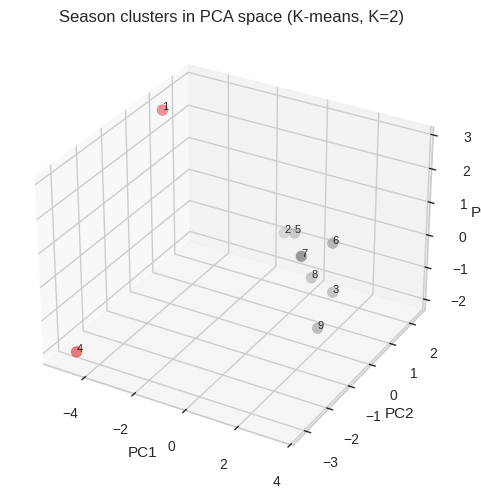

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    season_features['PC1'],
    season_features['PC2'],
    season_features['PC3'],
    c=season_features['kmeans_k2'],
    cmap='Set1',
    s=60
)

for _, row in season_features.iterrows():
    ax.text(row['PC1'], row['PC2'], row['PC3'],
            str(int(row['season'])), fontsize=8)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Season clusters in PCA space (K-means, K=2)')
plt.tight_layout()
plt.show()



## **5.4 Classification**

### **5.4.1 Creating Season Labels**

In [ ]:
# 1. Create binary "hard vs easy" label from hardness_index

median_hard = season_features['hardness_index'].median()
season_features['hard_label'] = (season_features['hardness_index'] > median_hard).astype(int)
# 1 = hard season, 0 = easy season

season_features[['season', 'hardness_index', 'hard_label', 'kmeans_k2']]

,season,hardness_index,hard_label,kmeans_k2
0,1,-1.429784,0,1
1,2,-0.233203,0,2
2,3,0.943764,1,2
3,4,-0.886488,0,1
4,5,-0.447224,0,2
5,6,0.314292,1,2
6,7,0.724766,1,2
7,8,0.291747,0,2
8,9,0.722130,1,2


In [ ]:
# 2. EDA: compare easy vs hard seasons on key features

eda_cols = ['mean_days_lasted', 'early_exit_rate',
            'mean_imdb_rating', 'mean_log_viewers', 'mean_log_nratings']

eda_summary = (
    season_features
    .groupby('hard_label')[eda_cols]
    .mean()
    .rename(index={0: 'easy', 1: 'hard'})
    .round(3)
)

eda_summary


,mean_days_lasted,early_exit_rate,mean_imdb_rating,mean_log_viewers,mean_log_nratings
hard_label,,,,,
easy,31.746,0.394,7.669,0.951,4.154
hard,48.925,0.200,8.027,0.890,3.974


### **5.4.2 Classifier Pipeline**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Features and target
X = season_features[['mean_days_lasted', 'early_exit_rate',
                     'mean_imdb_rating', 'mean_log_viewers', 'mean_log_nratings']]
y = season_features['hard_label']

# Train–test split (6 train, 3 test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=3,
    random_state=42,
    stratify=y
)

# Pipeline: scaling + logistic regression
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression())
])

pipe.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()), ('logreg', LogisticRegression())])

### **5.4.3 Confusion Matrix**

In [ ]:
y_pred = pipe.predict(X_test)

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3, zero_division=0))

Confusion matrix:
 [[2 0]
 [1 0]]
              precision    recall  f1-score   support

           0      0.667     1.000     0.800         2
           1      0.000     0.000     0.000         1

    accuracy                          0.667         3
   macro avg      0.333     0.500     0.400         3
weighted avg      0.444     0.667     0.533         3



In [ ]:
log_clf = pipe.named_steps['logreg']
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': log_clf.coef_[0]
}).sort_values('coef', ascending=False)




### **5.4.4 Predicted Labels**

In [ ]:
X_all = season_features[['mean_days_lasted', 'early_exit_rate',
                         'mean_imdb_rating', 'mean_log_viewers', 'mean_log_nratings']]

season_features['pred_hard_label'] = pipe.predict(X_all)

season_class_table = (
    season_features[['season', 'hard_label', 'pred_hard_label', 'hardness_index']]
    .sort_values('season')
)

season_class_table


,season,hard_label,pred_hard_label,hardness_index
0,1,0,0,-1.429784
1,2,0,0,-0.233203
2,3,1,1,0.943764
3,4,0,0,-0.886488
4,5,0,0,-0.447224
5,6,1,1,0.314292
6,7,1,1,0.724766
7,8,0,0,0.291747
8,9,1,0,0.722130


In [ ]:
mapping = {0: 'easy', 1: 'hard'}
season_class_table['true_class'] = season_class_table['hard_label'].map(mapping)
season_class_table['pred_class'] = season_class_table['pred_hard_label'].map(mapping)

season_class_table[['season','true_class','pred_class','hardness_index']]


,season,true_class,pred_class,hardness_index
0,1,easy,easy,-1.429784
1,2,easy,easy,-0.233203
2,3,hard,hard,0.943764
3,4,easy,easy,-0.886488
4,5,easy,easy,-0.447224
5,6,hard,hard,0.314292
6,7,hard,hard,0.724766
7,8,easy,easy,0.291747
8,9,hard,easy,0.722130


## **5.5 Conclusion**
**From K‑means on PCA:**
* Cluster 1 (easier, broad‑audience): Seasons 1 and 4.
* Cluster 2 (harder, prestige): Seasons 2, 3, 5, 6, 7, 8, 9.​

**From the supervised classifier table:**
* True easy (by hardness_index): 1, 2, 4, 5, 8.
* True hard: 3, 6, 7, 9.
* Predicted easy: 1, 2, 4, 5, 8, 9.
* Predicted hard: 3, 6, 7.
---
* Both methods agree that Seasons 1 and 4 form an easier, broad audience regime, and that Seasons 3, 6, and 7 are clearly in the harder, prestige style regime.
* The classifier refines the harder group by treating Seasons 2, 5, and 8 as borderline: in the PCA/K‑means view they sit with the hard cluster, but once we put a hard threshold on hardness_index and fit a supervised model, they are classified as “easy.”
* Season 9 is the one real disagreement: K means and the hardness_index mark it as hard, but the classifier predicts easy, which matches the single error in the confusion matrix and likely reflects limited data rather than a fundamentally different regime.

Overall, both clustering and classification tell a consistent story: Alone’s US seasons fall into an early, easier, broad‑audience regime (especially Seasons 1 and 4) and a later, harder “prestige” regime where contestants last longer and ratings are higher, but average viewers are lower, meaning increased difficulty improves perceived quality rather than mass reach.

 ## **6. Business Insight**

The analysis of Alone demonstrates that audience engagement is driven less by geographic extremeness and more by realized survival intensity. Variables such as contestant endurance duration, dispersion in survival outcomes, and frequency of medical evacuations better explain how viewers perceive and respond to each season. The evidence indicates that survival difficulty is multidimensional and structurally stable, with seasons naturally grouping into distinct intensity profiles rather than reflecting random environmental variation.

A consistent reach–prestige trade-off emerges across analytical methods. Seasons characterized by greater endurance demands and higher survival risk tend to receive stronger ratings on IMDb, suggesting that audiences associate higher difficulty with authenticity and quality. However, these same seasons attract smaller average viewership. Conversely, more moderate seasons tend to generate broader audience reach but receive comparatively lower critical appreciation. The persistence of this pattern across clustering techniques and regression validation confirms that the trade-off is structural rather than an artifact of model specification.

From a strategic standpoint, the findings suggest that programming decisions inherently involve balancing two competing objectives: maximizing audience size versus maximizing perceived quality. Rather than attempting to optimize both simultaneously, producers may benefit from adopting a portfolio approach. High-intensity seasons can strengthen brand equity, prestige, and long-term franchise value, while more accessible seasons can drive broader engagement and advertising revenue. Intentionally alternating between these difficulty profiles allows the show to manage this structural trade-off proactively and align season design with broader business objectives.

Overall, the results reposition survival difficulty not merely as a creative element, but as a strategic lever that directly shapes audience behavior, brand perception, and revenue potential.

#**2. Domain Question 1**

##**“How to improve viewership and rating by casting fairly and segmenting survivalists based on profession, age, days lasted, reason for tapping out, gender, location, and country.”**

###**2.1 Contestant level dataframe creation**

In [ ]:
df_person_season = df_clean.groupby(['season','name'], as_index=False).agg({
    'days_lasted': 'max',
    'age': 'first',
    'gender': 'first'
    # add more as needed
})
df_person_season_unique = df.drop_duplicates(subset='name', keep="first")
df_person_season_unique.head(2)


,version,season,id,name,age,gender,profession,city,state,country,...,location,lat,lon,date_drop_off,team,viewers,imdb_rating,n_ratings,item,item_detailed
0,US,1,Alan Kay,Alan Kay,40,Male,Corrections Officer,Blairsville,Georgia,United States,...,Quatsino,50.72444,-127.498056,None,None,1.9697,7.672727,101.545455,"[Saw, Axe, Sleeping bag, Pot, Ferro rod, Cante...","[Saw, Axe, Sleeping bag, Large 2-quart pot, Fe..."
1,US,1,Brant McGee,Brant McGee,44,Male,US Army Guard and Former US Coast Guard,Albemarle,North Carolina,United States,...,Quatsino,50.72444,-127.498056,None,None,1.9697,7.672727,101.545455,"[Tarp, Paracord, Axe, Sleeping bag, Pot, Ferro...","[12×12 ground sheet tarp, 550 paracord – 20m, ..."


###**2.2 Preprocessing**

In [ ]:
from sklearn.preprocessing import StandardScaler
#Dropping useless columns
dfps_clean = df_person_season_unique.drop(['version','date_drop_off','item_detailed','team','id'],axis = 1)

# Replacing missing exit reasons and state with "Unknown" as values are misssing based on M3
dfps_clean["reason_category"] = dfps_clean["reason_category"].fillna("Unknown")
dfps_clean["state"] = dfps_clean["state"].fillna("Unknown")
# First, imputing missing viewers using the median within each season
dfps_clean["viewers"] = dfps_clean["viewers"].fillna(dfps_clean.groupby("name")["viewers"].transform("median"))

# Then, filling an entire season 9 missing value with the overall median
dfps_clean["viewers"] = dfps_clean["viewers"].fillna(dfps_clean["viewers"].median())
#Selecting numeric variables
num_vars = [
    "lon",
    "viewers",
    "n_ratings",
    "days_lasted",
    "age",
    "imdb_rating",
    "lat"]
# Creating log versions as the values are skewed based on M3
dfps_clean["log_viewers"] = np.log1p(dfps_clean["viewers"])
dfps_clean["log_n_ratings"] = np.log1p(dfps_clean["n_ratings"])
dfps_clean["log_imdb_rating"] = np.log1p(dfps_clean["imdb_rating"])

# Dropping raw skewed versions
df_clean = dfps_clean.drop(columns=["viewers", "n_ratings"])
# Defining the numeric variables
dfps_clean['season'] = dfps_clean['season'].astype('category')
dfps_clean['result'] = dfps_clean['result'].astype('category')
dfps_clean = dfps_clean.drop(['viewers','n_ratings','imdb_rating'], axis =1)
numeric_cols = dfps_clean.select_dtypes(include=["int64","float64"]).columns
df_num = dfps_clean[numeric_cols]


### **2.3 Standardization of Features and PCA creation**

In [ ]:
# Standardising the features
from sklearn.decomposition import PCA
scaler = StandardScaler()
pca = PCA()
X_scaled = scaler.fit_transform(df_num)
df_numeric_normalized = pd.DataFrame(X_scaled, columns = df_num.columns)
transformed_data_df = pd.DataFrame(pca.fit_transform(X_scaled), columns = ['PC1', 'PC2', 'PC3','PC4', 'PC5', 'PC6','PC7'])
transformed_data_df.head(6)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-1.775998,-0.764183,1.312123,0.429866,0.669599,1.167722,0.077895
1,-2.436542,-0.652963,0.769326,0.607267,-0.903155,0.928003,0.073462
2,-2.523639,-0.708859,0.668723,0.256738,-0.965551,0.886907,0.068869
3,-2.452453,-0.792236,0.697846,-0.140699,-0.649369,0.903142,0.065291
4,-2.587733,-1.045891,0.472942,-1.569254,-0.403482,0.816878,0.048678
5,-2.599234,-0.905323,0.520531,-0.831522,-0.715714,0.831345,0.056477


### **2.4 PCs variance explaination analysis**

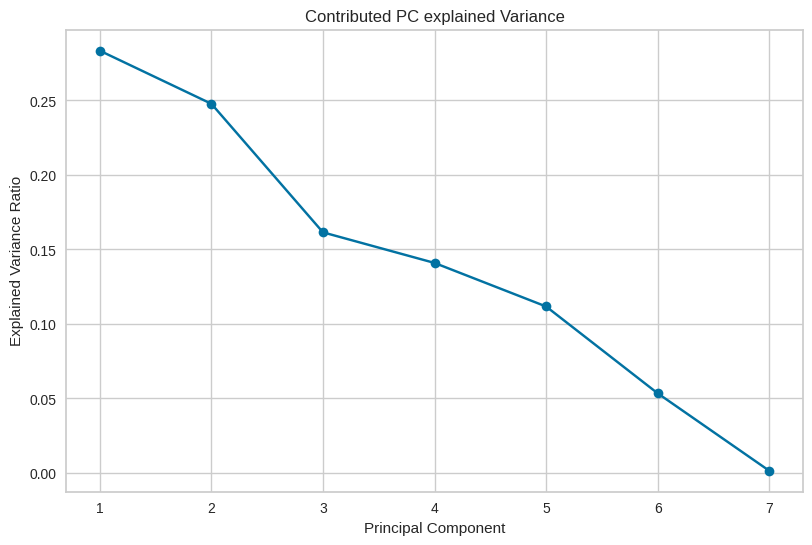

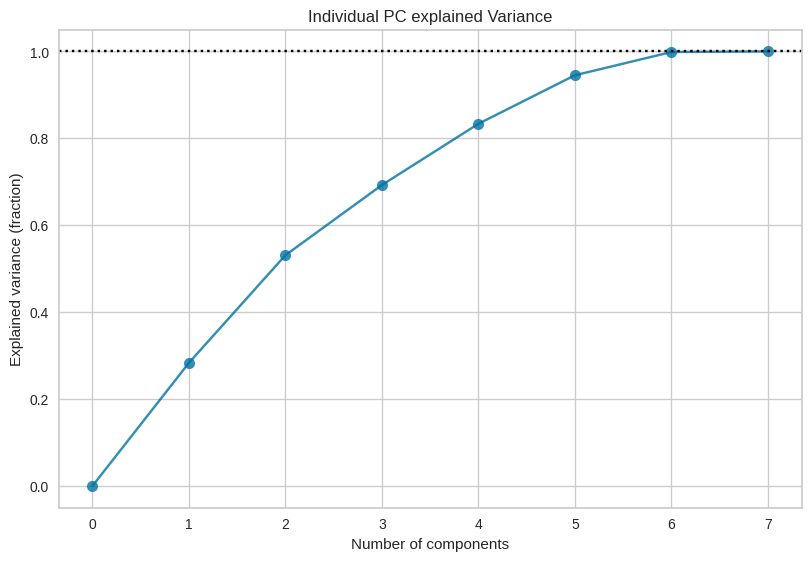

In [ ]:
from sklearn.decomposition import PCA
from psynlig import (
    pca_explained_variance,
    pca_explained_variance_bar,
)
explained_variance = pca.explained_variance_ratio_
# Visualising explained variance by component to choose dimensionality

plt.figure(figsize=(9.5,6))
plt.plot(range(1, len(explained_variance)+1),
         explained_variance,
         marker='o')

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.xticks(range(1, len(explained_variance)+1))
plt.title('Contributed PC explained Variance')
plt.show()
from psynlig import (
    pca_explained_variance,
    pca_explained_variance_bar,
)

_, ax = pca_explained_variance(pca,  marker='o', markersize=8, alpha=0.8)
plt.title('Individual PC explained Variance')
plt.show()

In [ ]:
# Total variance explained by the first 3 PCs
total_variance = explained_variance[:3].sum()
print(f"{total_variance * 100:.2f}%")

69.25%


### **2.5 Loadings - how each feature contributes to a PC**

In [ ]:
# Contribution of each feature to each PC
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=df_num.columns)
loadings_df.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
age,0.054,0.172,0.119,0.945,-0.243,0.044,0.011
days_lasted,0.390,-0.018,0.339,0.145,0.830,0.148,0.005
lat,-0.140,0.656,-0.215,-0.098,0.072,0.629,0.305
lon,0.568,-0.393,-0.110,-0.033,-0.268,0.221,0.624
log_viewers,-0.350,-0.575,0.037,0.092,0.001,0.680,-0.272
log_n_ratings,-0.447,-0.028,0.722,-0.078,-0.062,-0.078,0.512
log_imdb_rating,0.425,0.233,0.539,-0.248,-0.413,0.250,-0.424


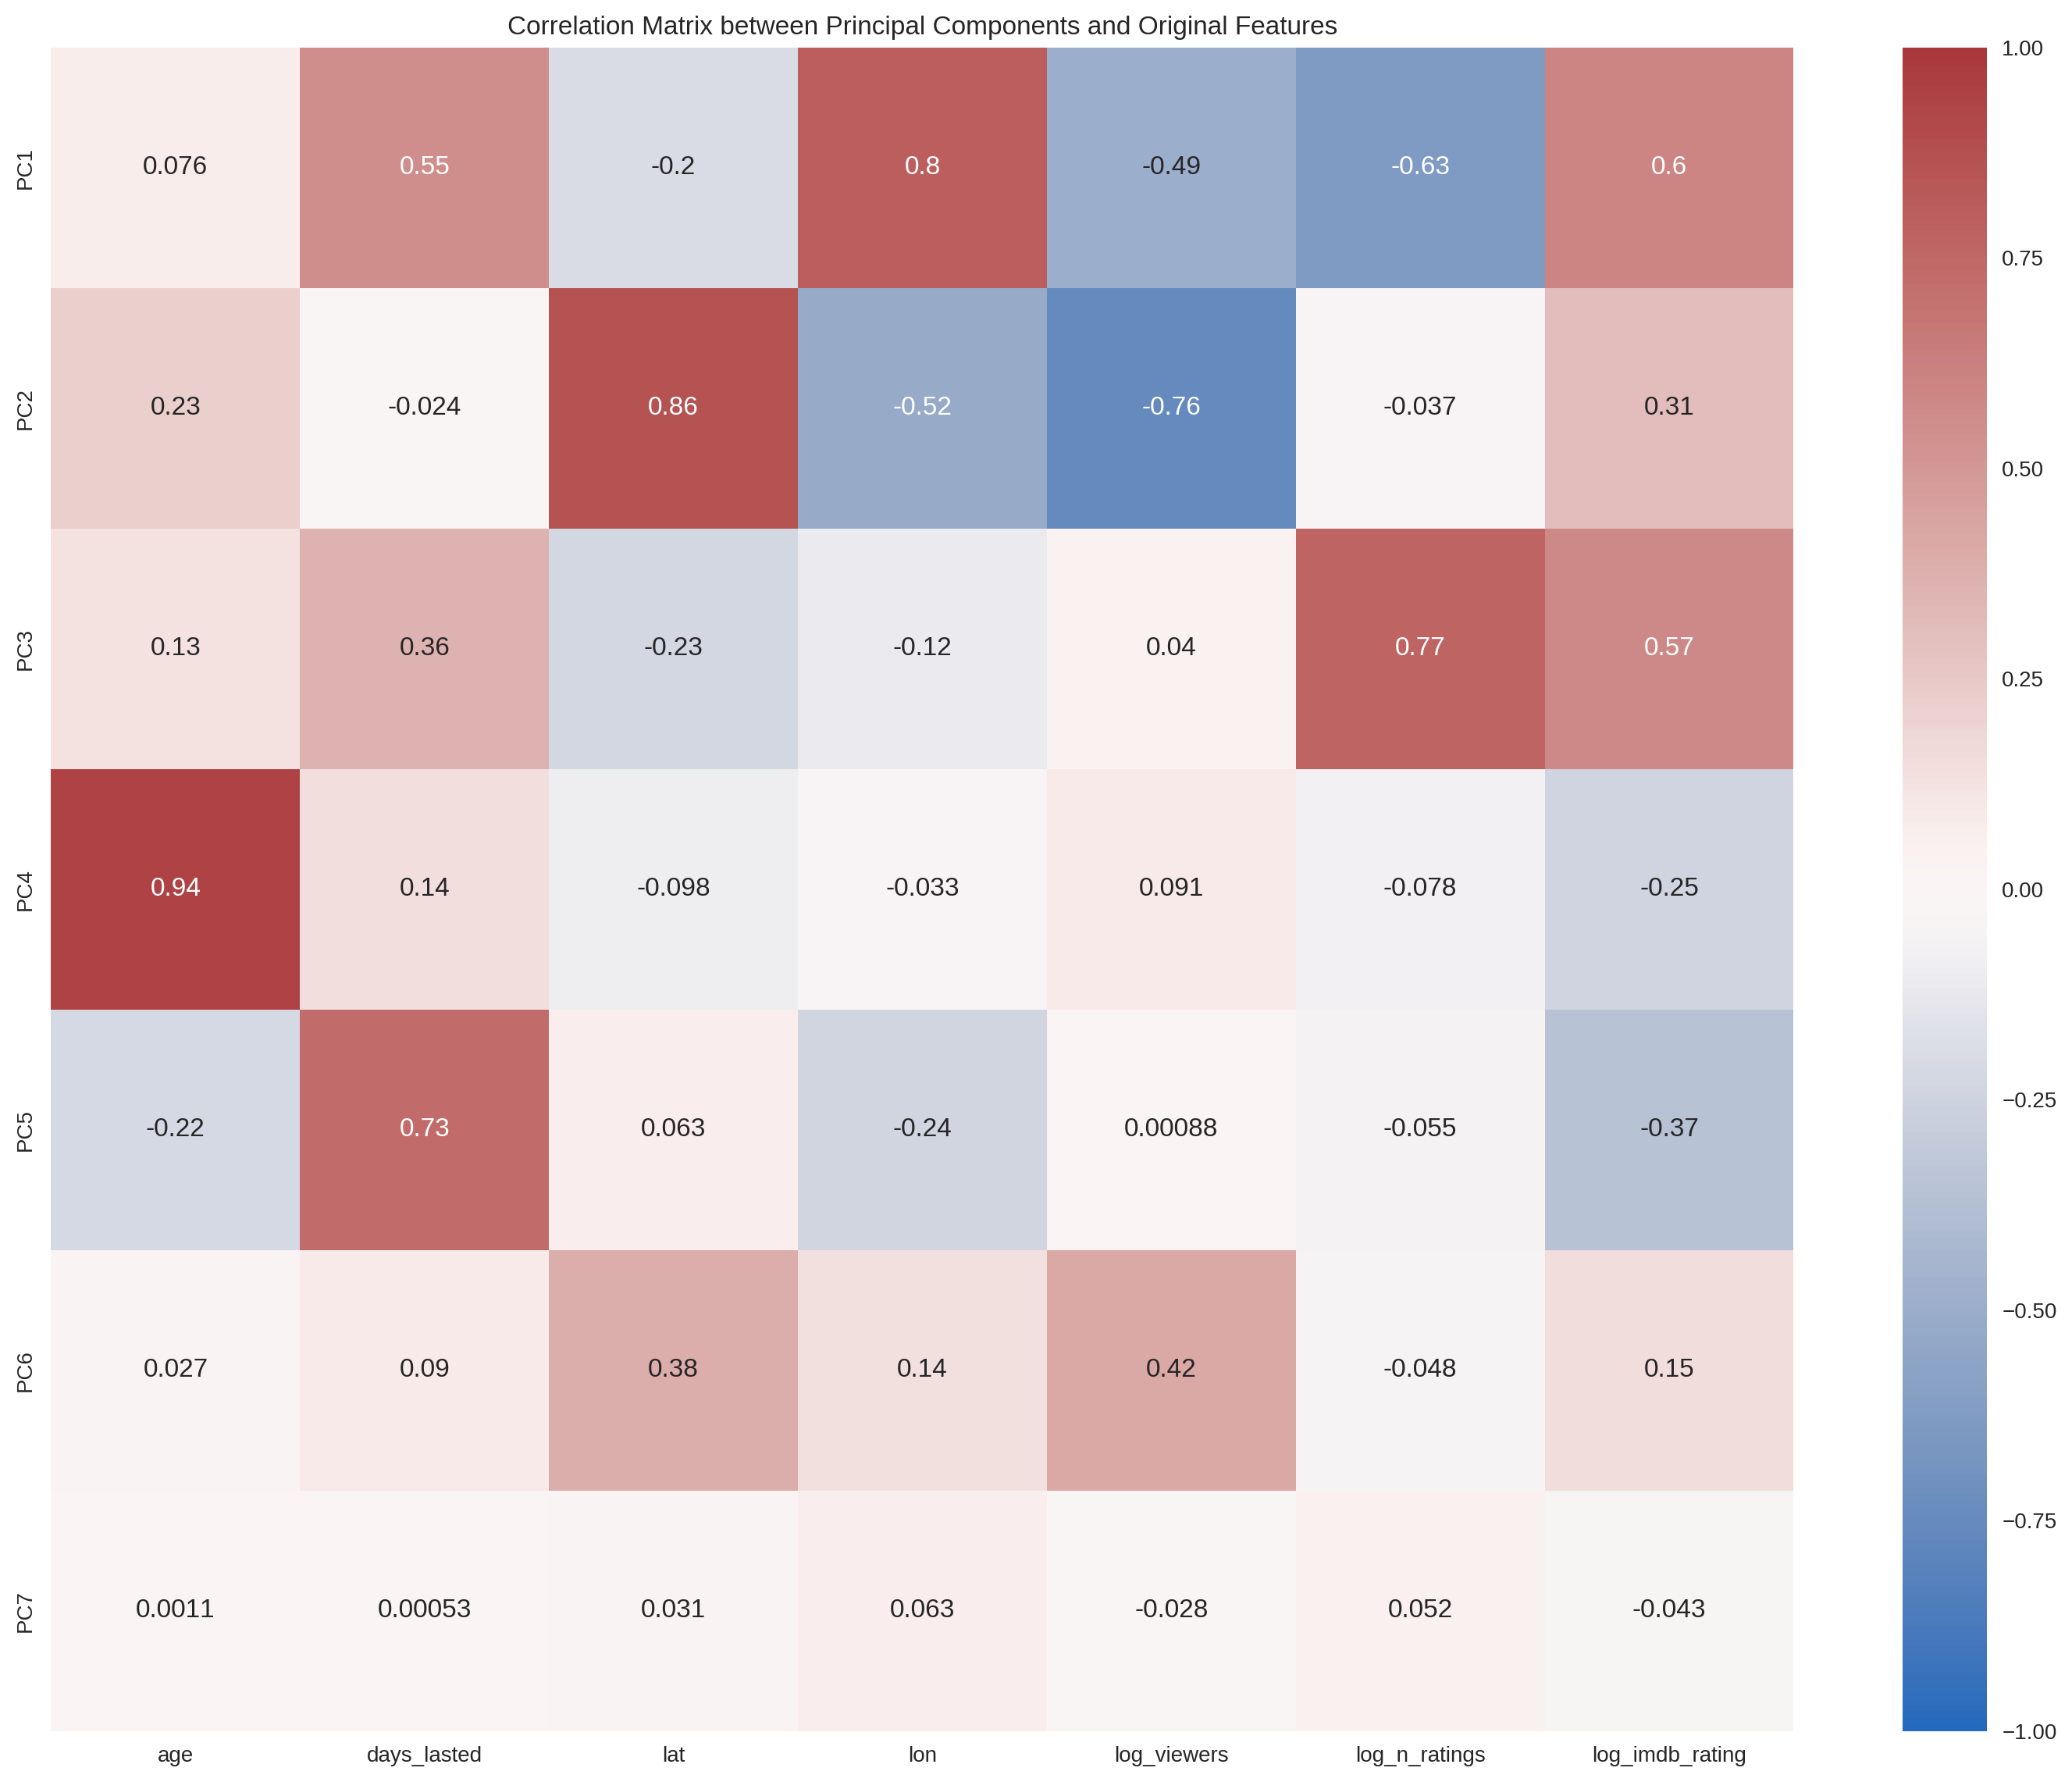

In [ ]:
# Concatenate the PCs and the normalized original features
combined_df = pd.concat([transformed_data_df, df_numeric_normalized.reset_index(drop=True)], axis=1)

# Calculate the correlation matrix
correlation_pcs_original = combined_df.corr().loc[transformed_data_df.columns, df_numeric_normalized.columns]

plt.figure(figsize=(18, 14), dpi=200)
sns.heatmap(correlation_pcs_original, annot=True, cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix between Principal Components and Original Features')
plt.show()

([<Figure size 800x550 with 1 Axes>,
  <Figure size 800x550 with 1 Axes>,
  <Figure size 800x550 with 1 Axes>],
 [<Axes: title={'center': 'Loading coefficients for PC1'}, xlabel='Variables', ylabel='Coefficient'>,
  <Axes: title={'center': 'Loading coefficients for PC2'}, xlabel='Variables', ylabel='Coefficient'>,
  <Axes: title={'center': 'Loading coefficients for PC3'}, xlabel='Variables', ylabel='Coefficient'>])

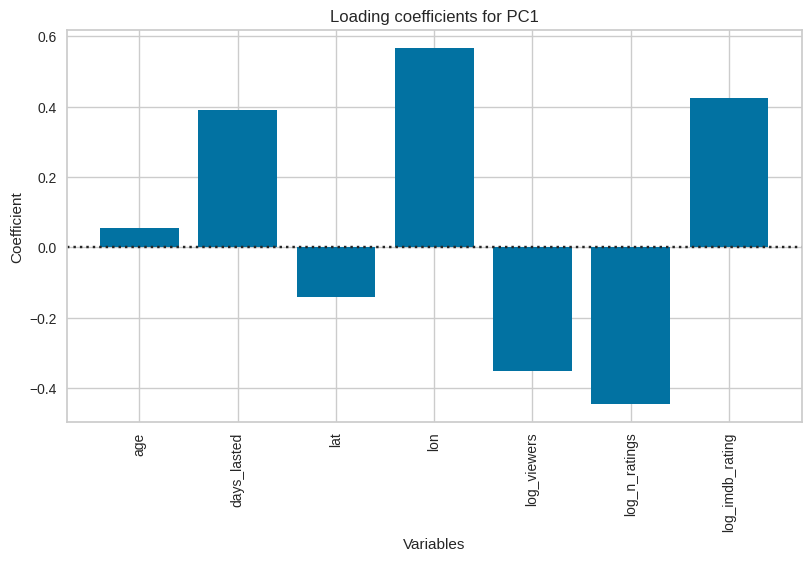

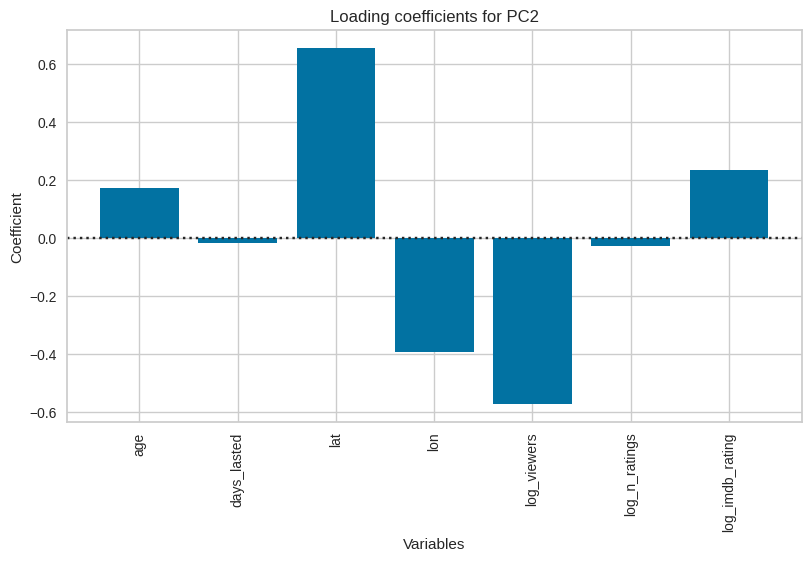

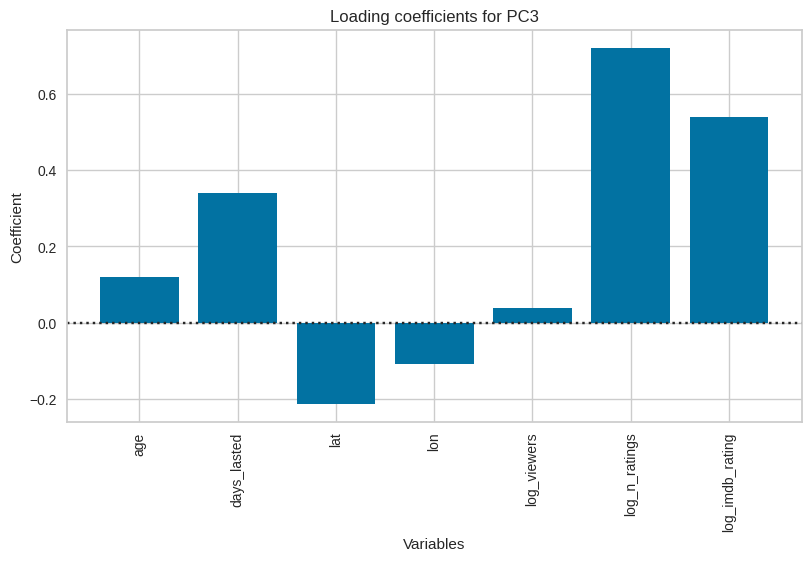

In [ ]:
from psynlig import pca_1d_loadings

pca_1d_loadings(
    pca,
    df_numeric_normalized.columns,
    select_components={1, 2,3},
    plot_type="bar",
)


### **2.6 Finding the n_clusters based on distortion and silhouette score**

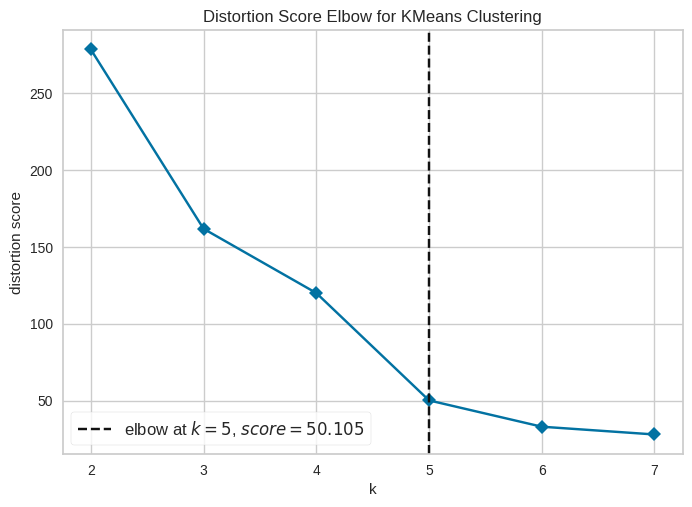

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# Refitting PCA keeping only the first 3 components
pca = PCA(n_components=3)
X_reduced = pca.fit_transform(X_scaled)
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=42)

visualizer = KElbowVisualizer(
    model,
    k=(2, 8),
    metric='distortion',
    timings=False)

visualizer.fit(X_reduced)
visualizer.show()

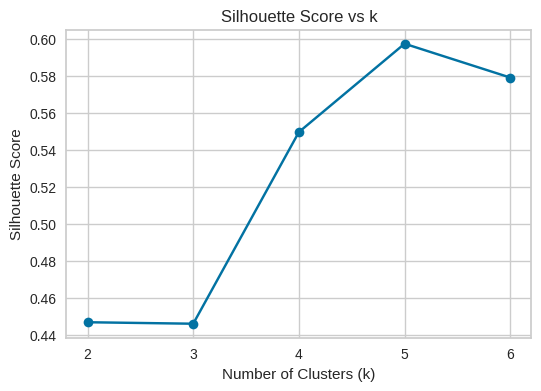

k=2: silhouette=0.447
k=3: silhouette=0.446
k=4: silhouette=0.550
k=5: silhouette=0.598
k=6: silhouette=0.579


In [ ]:
from sklearn.metrics import silhouette_score
sil_scores = []
k_values = range(2, 7)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_reduced)
    sil = silhouette_score(X_reduced, labels)
    sil_scores.append(sil)

# Plotting
plt.figure(figsize=(6,4))
plt.plot(k_values, sil_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.xticks(k_values)
plt.show()

for k, score in zip(k_values, sil_scores):
    print(f"k={k}: silhouette={score:.3f}")

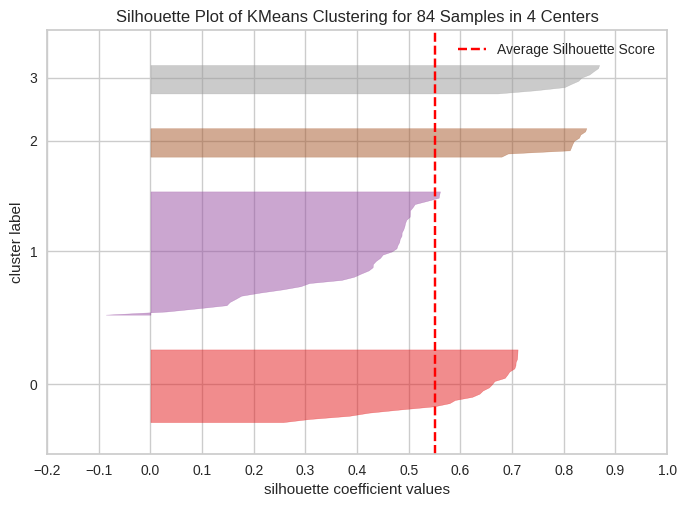

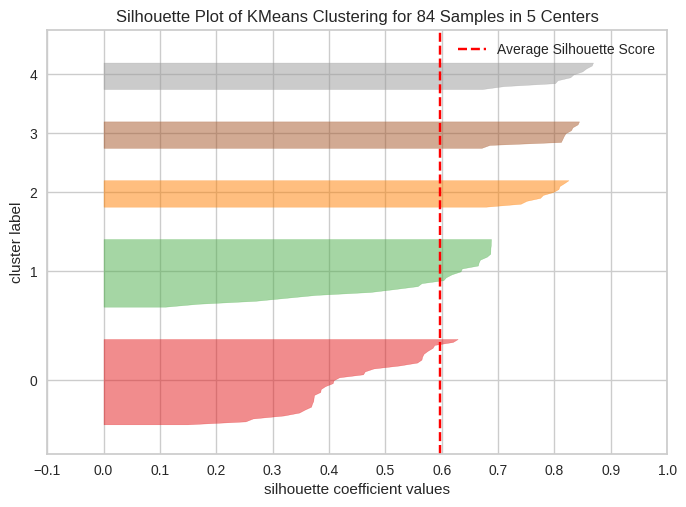

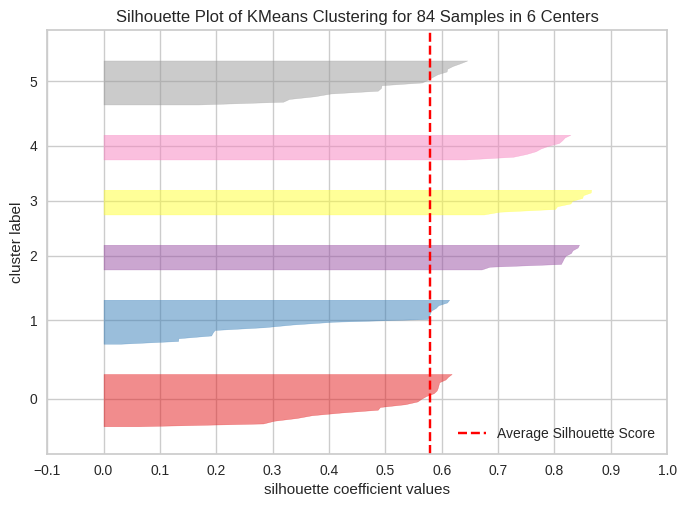

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer

for k in [4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    visualizer = SilhouetteVisualizer(km)
    visualizer.fit(X_reduced)
    visualizer.show()

**Observation:** For KMeans, number of cluster = 4, is the most appropriate due to its elbow position or low distortion and high silhouette score. Compared to other number of clusters 5 and 6, when number of cluster = 4 the average silhoute score is 0.6. There has been an improvement since M3, due to teh addition of the pre processing steps.

### **2.7  Custering and Plotting**

In [ ]:
n_cluster = 4
kmeans_result = KMeans(n_cluster).fit(transformed_data_df)
kmeans_result.cluster_centers_

array([[-1.50308559, -0.12924883, -1.08247036, -0.50323998,  0.05850446,
        -0.29853253,  0.01618377],
       [ 1.26117537,  0.95403179,  0.10089335, -0.32566027, -0.28609432,
         0.16268428,  0.04178199],
       [ 1.19949535, -2.92833505,  0.76538009,  0.16859953, -0.25465305,
        -0.64039996,  0.00443635],
       [-0.95956721,  0.08239602,  0.14913279,  0.50430575,  0.34367659,
         0.19009756, -0.0508132 ]])

In [ ]:
#Cluster labels
import plotly.express as px
transformed_data_df['cluster_labels_k'] = kmeans_result.labels_
px.scatter_3d(transformed_data_df, x='PC1', y='PC2',z ='PC3', color='cluster_labels_k')

### **2.8 Labelling the clusters and Analysis**

In [ ]:
dfps_with_clusters = dfps_clean.copy()

dfps_with_clusters['clusters_k_pca'] = transformed_data_df['cluster_labels_k'].values

In [ ]:
cluster_members = (
    dfps_with_clusters
    .sort_values(['clusters_k_pca', 'season', 'name'])
    [['clusters_k_pca', 'season', 'name', 'days_lasted', 'log_imdb_rating']]
)

cluster_summary = (
    dfps_with_clusters
    .groupby('clusters_k_pca', as_index=False)
    .agg(
        n_contestants = ('name', 'nunique'),
        avg_days      = ('days_lasted', 'mean'),
        avg_age       = ('age', 'mean'),
        avg_imdb      = ('log_imdb_rating', 'mean'),
        avg_lat     = ('lat', 'mean'),
        avg_lon     = ('lon', 'mean'),
        avg_view = ('log_viewers', 'mean'),
        avg_rating = ('log_n_ratings', 'mean')
    )
)

cluster_members
cluster_summary


,clusters_k_pca,n_contestants,avg_days,avg_age,avg_imdb,avg_lat,avg_lon,avg_view,avg_rating
0,0,14,11.142857,31.642857,2.129948,50.724440,-127.498056,0.953987,4.065495
1,1,30,47.133333,38.166667,2.207650,60.886852,-97.425278,0.852194,3.921613
2,2,10,54.300000,36.700000,2.177022,-41.000000,-68.000000,1.000779,4.130355
3,3,30,41.866667,41.366667,2.154855,50.905182,-126.348704,0.968732,4.224438


**Inferences:**

- **Cluster 0** : A small group of 14 contestants who have the lowest survival spirit (last longer), with an average of 31 years of age and medium level ofviewership and lowest ratings.

- **Cluster 1**:  A large group of 30 contestants who have a second highest survival spirit (days lasted are medicore), 38 years old and lower level of viewership and highest ratings

- **Cluster 2** : A small group of 10 contestants who had the highest survival spirit, with an average of 36 years of age and second highest ratings and viewership.

- **Cluster 3** : A large group of 30 contestants who have the second lowest survival spirit, with an average of 41 years of age and highest level of viewership and second lowest ratings

### **2.9 Implementing association rules to the new cluster labels formed and categorical variables**

In [ ]:
new_df = dfps_with_clusters[['profession','clusters_k_pca', 'result','reason_category','location']]

In [ ]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
new_df = pd.get_dummies(new_df, columns=new_df.columns)
#Apriori min support
min_support = 0.01
#Max lenght of apriori n-grams
frequent_c = apriori(new_df, use_colnames=True, min_support=min_support)

### **2.10 Deeper dive into different clusters**

#### **2.10.1 Cluster 0**

In [ ]:
rules0 = association_rules(frequent_c, metric='lift', min_threshold=1.1)
rulesc0 = rules0[rules0['antecedents'] ==  frozenset({'clusters_k_pca_0'})]
rulesc0 = rulesc0.sort_values(by=['confidence','lift','support'], ascending=False).head(10)

In [ ]:
rulesc0['consequents'].values

array([frozenset({'location_Quatsino '}),
       frozenset({'reason_category_Family / personal'}),
       frozenset({'location_Quatsino ', 'reason_category_Family / personal'}),
       frozenset({'location_Quatsino'}),
       frozenset({'location_Quatsino ', 'reason_category_Medical / health'}),
       frozenset({'result_6', 'reason_category_Family / personal'}),
       frozenset({'result_6'}),
       frozenset({'location_Quatsino', 'reason_category_Family / personal'}),
       frozenset({'profession_Blacksmith'}),
       frozenset({'profession_Blacksmith', 'result_7'})], dtype=object)

**Inferences Cluster 0**

A small group of 10 contestants who have a low survival spirit, with an average of 31 years of age and medium level of viewership and lowest ratings. They tap out due to family or personal reasons and have medical issues this cluster can be seen at the location at Quatsino. They are blacksmiths and are mostly below averagers in terms of surviving.

#### **2.10.2 Cluster 1**

In [ ]:
rules1 = association_rules(frequent_c, metric='lift', min_threshold=2)
rulesc1 = rules1[rules1['antecedents'] ==  frozenset({'clusters_k_pca_1'})]
rulesc1 = rulesc1.sort_values(by=['confidence','lift','support'], ascending=False).head(10)

In [ ]:
rulesc1['consequents'].values

array([frozenset({'location_Great Slave Lake'}),
       frozenset({'location_Great Slave Lake', 'reason_category_Medical / health'}),
       frozenset({'location_Nunatsiavut'}),
       frozenset({'location_Nunatsiavut', 'reason_category_Medical / health'}),
       frozenset({'profession_Homesteader'}),
       frozenset({'profession_Hunting Guide'}),
       frozenset({'reason_category_Medical / health', 'profession_Homesteader'}),
       frozenset({'location_Great Slave Lake', 'profession_Homesteader'}),
       frozenset({'location_Great Slave Lake', 'profession_Hunting Guide'}),
       frozenset({'location_Great Slave Lake', 'result_1'})], dtype=object)

**Inference Cluster 1:** A large group of 30 contestants who have the second highest survival spirit, are 38 years old and lower level of viewership but high ratings who tap out due to medical or health reasons and this cluster can be seen at the location at Great Slave lake and Nunatsiavut. They are hunting guide or homesteader. They comprise a mix of winners and averagers.



#### **2.10.3 Cluster 2**

In [ ]:
rules2 = association_rules(frequent_c, metric='lift', min_threshold=2)
rulesc2 = rules2[rules2['antecedents'] ==  frozenset({'clusters_k_pca_2'})]
rulesc2 = rulesc2.sort_values(by=['confidence','lift','support'], ascending=False).head(10)

In [ ]:
rulesc2['consequents'].values

array([frozenset({'location_Patagonia'}),
       frozenset({'reason_category_Medical / health', 'location_Patagonia'}),
       frozenset({'location_Patagonia', 'reason_category_Family / personal'}),
       frozenset({'profession_Accountant'}),
       frozenset({'profession_Biologist & Forrester'}),
       frozenset({'profession_Boat builder'}),
       frozenset({'profession_Bushcraft Instructor'}),
       frozenset({'profession_Drywaller'}),
       frozenset({'profession_Herbalist'}),
       frozenset({'profession_High School Teacher'})], dtype=object)

**Inferences Cluster 2**

 A small group of 10 contestants who have a highest survival spirit with an average of 36 years of age contributed second highest ratings and viewership. This cluster is more likely to occur in the location of Patagonia.  The also priroritize family or personal life and have medical issues. These are neither loosers no winners they had the position of below average. They are Accountants, Biologist and Teachers.

#### **2.10.4 Cluster 3**

In [ ]:
rules3 = association_rules(frequent_c, metric='lift', min_threshold=1.7)
rulesc3 = rules3[rules3['antecedents'] ==  frozenset({'clusters_k_pca_3'})]
rulesc3 = rulesc3.sort_values(by=['confidence','lift','support'], ascending=False).head(10)

In [ ]:
rulesc3['consequents'].values

array([frozenset({'location_Quatsino'}),
       frozenset({'location_Chilko Lake'}),
       frozenset({'location_Quatsino', 'reason_category_Family / personal'}),
       frozenset({'reason_category_Medical / health', 'location_Chilko Lake'}),
       frozenset({'result_3', 'reason_category_Family / personal'}),
       frozenset({'reason_category_Medical / health', 'location_Quatsino'}),
       frozenset({'profession_Carpenter', 'reason_category_Family / personal'}),
       frozenset({'location_Quatsino', 'result_1'}),
       frozenset({'location_Quatsino ', 'result_1'}),
       frozenset({'result_2', 'location_Quatsino'})], dtype=object)

**Inferences Cluster 3**

A small group of 30 contestants who have the second lowest survival spirit, who have/ had to medical or health reasons with an average of 41 years of age contributed to highest level of viewership and second lowest ratings are more likely to occur at location Quatsino and Chilko Lake. These have professions like carpenting, they leave out as they prioritize family and personal life and have medical or health issues. These are people who are accountant, biologist and animal farmer. These are the winners and the runner ups

###**2.11 Insights for contestant level analysis**


-  Cluster 3 had the second lowest survival spirit but gave the highest viewership but lowest imdb ratings. The casting directors must cast these survivalists to ensure higher audience participation but however change the content/ location/ season such that people are attracted
- Diversify contestants' profiles to be fairer and unbiased




# **6. Reference**

1. [wiki page](https://en.wikipedia.org/wiki/Alone_(TV_series)
2. [stat.cmu](https://www.stat.cmu.edu/capstoneresearch/fall2023/315files_f23/team10.html)
3. [stackoverflow..com](https://stackoverflow.com/questions)
4. [Clustering - Sckit](https://scikit-learn.org/stable/modules/clustering.html)
5. [Clustering](https://www.geeksforgeeks.org/machine-learning/clustering-in-machine-learning/)
6. [Alone News](https://www.legit.ng/entertainment/tv-shows/1553658-has-died-how-dangerous-tv-show/)
7. [Alone contestants](https://www.reddit.com/r/Alonetv/comments/12tcujd/alone_data_set_for_analysis/)
8. [Professor's Git Hub](https://github.com/elhamod/BA820)

# **7. Generative AI Disclosure**

* ChatGPT was used selectively for writing and coding assistance, under full team validation and oversight.
* Code standardization: Helped align style and reduce warnings; all notebooks were re‑run end‑to‑end by the team to verify correctness.
* Writing and documentation: Assisted with grammar and wording; every numeric statement was cross‑checked against our own tables and figures, and text was kept only when it matched our results.
* Visualization refinement: Suggested clearer axis labels, legends, and color choices; all plots were regenerated directly from our data and reviewed by the team.
* Generative AI was not used to derive conclusions or interpret results; final interpretations and decisions are entirely our own.*

* Links to ChatGPT Conversation:
[Chat GPT Link](https://chatgpt.com/share/69961387-2ad0-8010-b1c7-449afe85b8eb)

https://chatgpt.com/share/699d1429-d51c-800c-8b75-d65ae302a2de

https://chatgpt.com/share/699cf99d-c420-8005-82ae-f9f7b0155959
